In [353]:
# base libraries
import pandas as pd
import numpy as np 
import pingouin as pg
import os

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.colors as mcolors
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.power import TTestIndPower
from statsmodels.formula.api import ols

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.cluster import KMeans

from sklearn.preprocessing import OneHotEncoder

from math import sqrt

import scipy.stats
from scipy import stats
from scipy.stats import ttest_ind

from datetime import datetime, timedelta

import researchpy as rp

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.validation")

In [187]:
# Specify the directory and filename
save_dir = "./Images/"

In [188]:
model_data = pd.read_csv('Per_Interaction_Data_Merged.csv')

model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust2,MWL,Assessment,Frechet_Distance,Gaze_on_AGV,User_Relative_Speed,User_Trajectory,AGV_Approaching,AGV_User_Combination,AGV_Path_Complexity
0,1,High,2024-5-3,14,28,53,1,15:2:48,15:3:38,219,...,52.0,63.0,1.812,NaN,0.063,137.683,Diagonal,North,North - Diagonal,Complex
1,1,High,2024-5-3,14,28,53,2,15:3:47,15:4:29,0,...,52.0,63.0,1.812,NaN,0.038,109.577,Straight,South,South - Straight,Straight
2,1,High,2024-5-3,14,28,53,3,15:4:37,15:5:34,268,...,52.0,63.0,1.812,NaN,0.069,131.592,Diagonal,South,South - Diagonal,Complex
3,1,High,2024-5-3,14,28,53,4,15:5:46,15:6:37,779,...,52.0,63.0,1.812,NaN,0.231,95.205,Straight,Northeast,Northeast - Straight,Complex
4,1,High,2024-5-3,14,28,53,5,15:6:41,15:7:44,868,...,52.0,63.0,1.812,NaN,0.234,185.999,Straight,Northwest,Northwest - Straight,Complex


In [189]:
# Drop some repetetive columns
print(model_data.columns)

# If you encountered some rows being duplicate, just drop them by specifying the name
# model_data = model_data.drop(columns=['AGV_Approaching.1','User_Trajectory.1','Gaze_on_AGV.1','Cross_First.1','User_Relative_Speed.1','Frechet_Distance.1'])

model_data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Frechet_Distance', 'Gaze_on_AGV', 'User_Relative_Speed',
       'User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination',
       'AGV_Path_Complexity'],
      dtype='object')


Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Frechet_Distance', 'Gaze_on_AGV', 'User_Relative_Speed',
       'User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination',
       'AGV_Path_Complexity'],
      dtype='object')

In [190]:
# Drop PID = 5, 18, 23, 25. The first three don't have any recorded data, the last one, only has one round of data.
model_data = model_data.drop(model_data[model_data['PID'].isin([5, 18, 23, 25])].index)

### Adding Interaction No, which will come handy for "fill_between" plots

In [191]:
model_data["Interaction No"] = model_data.groupby(['PID', 'DRate']).cumcount() + 1

In [192]:
model_data.iloc[120:145]

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,MWL,Assessment,Frechet_Distance,Gaze_on_AGV,User_Relative_Speed,User_Trajectory,AGV_Approaching,AGV_User_Combination,AGV_Path_Complexity,Interaction No
120,4,Low,2024-5-15,15,11,37,10,15:18:37,15:19:29,635,...,78.000,1.375,NaN,0.168,126.007,Straight,West,West - Straight,Straight,10
121,4,Low,2024-5-15,15,11,37,11,15:19:38,15:20:13,221,...,78.000,1.375,NaN,0.100,209.531,Diagonal,East,East - Diagonal,Complex,11
122,4,Low,2024-5-15,15,11,37,12,15:20:19,15:21:38,231,...,78.000,1.375,NaN,0.062,191.618,Straight,Southeast,Southeast - Straight,Complex,12
123,4,Low,2024-5-15,15,11,37,13,15:21:58,15:22:33,0,...,78.000,1.375,NaN,0.000,139.329,Straight,Southwest,Southwest - Straight,Complex,13
124,4,Low,2024-5-15,15,11,37,14,15:22:36,15:23:17,541,...,78.000,1.375,NaN,0.188,180.147,Diagonal,Southeast,Southeast - Diagonal,Straight,14
125,4,Low,2024-5-15,15,11,37,16,15:24:53,15:25:36,479,...,78.000,1.375,NaN,0.164,165.461,Diagonal,West,West - Diagonal,Complex,15
126,6,High,2024-5-20,14,38,42,1,14:39:3,14:40:33,436,...,51.333,1.188,NaN,0.084,83.891,Diagonal,North,North - Diagonal,Complex,1
127,6,High,2024-5-20,14,38,42,2,14:40:39,14:41:37,0,...,51.333,1.188,NaN,0.176,87.667,Straight,South,South - Straight,Straight,2
128,6,High,2024-5-20,14,38,42,3,14:41:43,14:42:43,488,...,51.333,1.188,NaN,0.189,144.163,Diagonal,South,South - Diagonal,Complex,3
129,6,High,2024-5-20,14,38,42,4,14:42:48,14:43:49,454,...,51.333,1.188,NaN,0.148,79.144,Straight,Northeast,Northeast - Straight,Complex,4


In [8]:
model_data_filtered = model_data[(model_data['PID'].between(1, 46))]

In [9]:
# model_data_filtered.to_csv('Per_Interaction_Data_Merged_16.csv', index = False)

## Data Visulaization

### Distribution Fitting

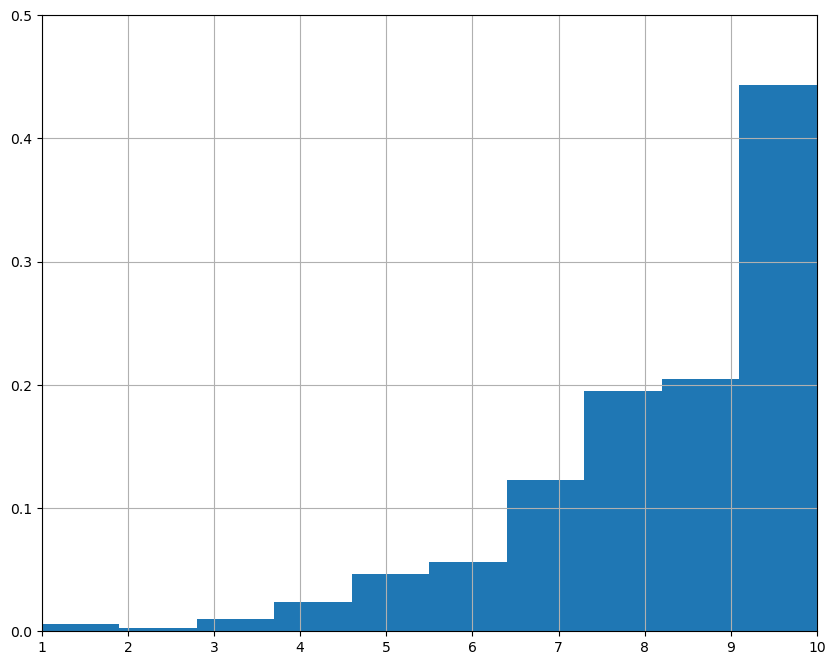

In [349]:
plt.figure(figsize=(10,8))
plt.xlim(1,10)
plt.ylim(0,0.5)
plt.grid(True)
plt.hist(model_data['Trust'], density=True)
plt.show()

Gamma distribution parameters, [a_fit, loc_fit, scale_fit]: [278.3361333280592, -22.862821398114477, 0.11243350651746747]


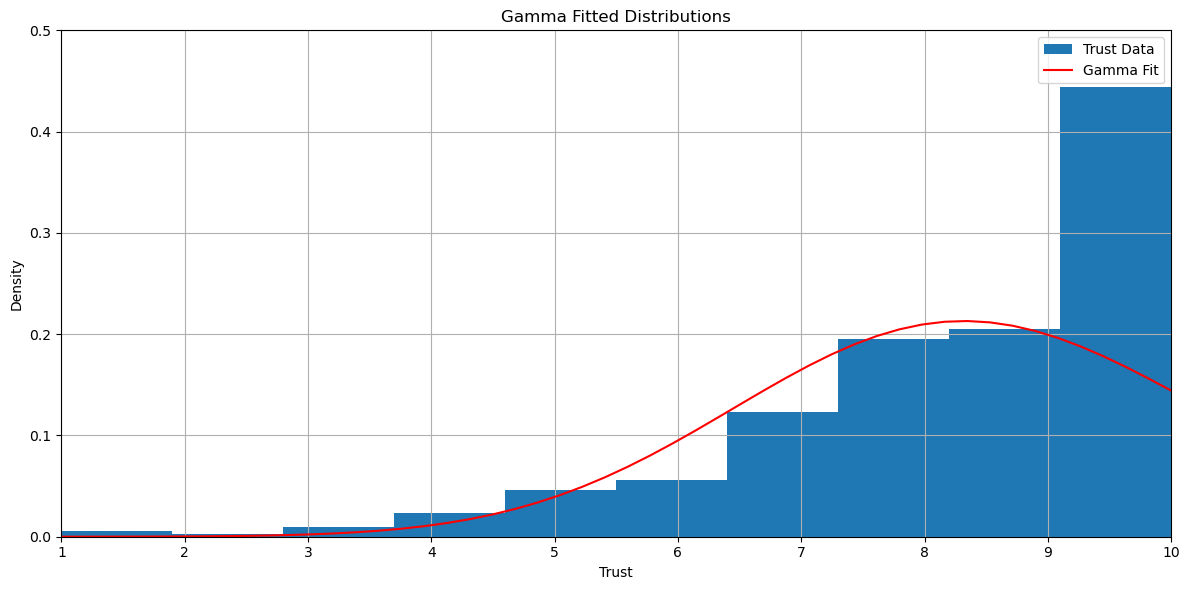

In [361]:
[a_fit, loc_fit, scale_fit] = scipy.stats.gamma.fit(model_data['Trust'])

print("Gamma distribution parameters, [a_fit, loc_fit, scale_fit]:",[a_fit, loc_fit, scale_fit])
#gamma_params = stats.gamma.fit(model_data['Trust'])

#trust_min = model_data['Trust'].min()
#trust_max = model_data['Trust'].max()
#normlized_trust_data = (model_data['Trust']-trust_min)/(trust_max - trust_min)
#beta_params = scipy.stats.beta.fit(normlized_trust_data)

# Printing the parameters of both distributions
# print("Gamma distribution parameters:", gamma_params)
# print("Beta distribution parameters:", beta_params)

# Generate some data points for each distribution
x_gamma = np.linspace(min(model_data['Trust']), max(model_data['Trust']))
#x_beta = np.linspace(0,1,100)

#Plotting Distributions
plt.figure(figsize=(12,6))

plt.hist(model_data['Trust'], density=True, label = 'Trust Data')

#Gamma distribution plot
plt.plot(x_gamma, scipy.stats.gamma.pdf(x_gamma, a_fit, loc = loc_fit, scale=scale_fit), 'r-', label = 'Gamma Fit')

#Gamma distribution plot
#plt.plot(x_beta*(trust_max - trust_min) + trust_min, stats.beta.pdf(x_beta, *beta_params), 'b-', label = 'Beta fit')
plt.xlim(1,10)
plt.ylim(0,0.5)
plt.grid(True)
plt.xlabel('Trust')
plt.ylabel('Density')
plt.legend(loc='best')
plt.title('Gamma Fitted Distributions')
plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Gamma_Fitted_Distributions_as_a_trust_dynamic_model_{timestamp}.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)
plt.show()

### With Respect to Decelaration Rate

In [125]:
# Group Data by Interaction No
# 1.1. 
grouped_for_fill_between_visualization_for_trust = model_data_filtered.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

# Calculate the confidence intervals for trust
grouped_for_fill_between_visualization_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_for_trust['Trust_ci']
grouped_for_fill_between_visualization_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_for_trust['Trust_ci']

# Calculate the confidence intervals for safety
# 1.2. 
grouped_for_fill_between_visualization_for_Safe = model_data_filtered.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_for_Safe['Safe_ci'] = grouped_for_fill_between_visualization_for_Safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_for_Safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_Safe['Safe_count']-1)
grouped_for_fill_between_visualization_for_Safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_for_Safe['Safe_mean'] - grouped_for_fill_between_visualization_for_Safe['Safe_ci']
grouped_for_fill_between_visualization_for_Safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_for_Safe['Safe_mean'] + grouped_for_fill_between_visualization_for_Safe['Safe_ci']

# Calculate the confidence intervals for comfort

grouped_for_fill_between_visualization_for_Comfort = model_data_filtered.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()


grouped_for_fill_between_visualization_for_Comfort['Comfort_ci'] = grouped_for_fill_between_visualization_for_Comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_for_Comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_Comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_for_Comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_for_Comfort['Comfort_mean'] - grouped_for_fill_between_visualization_for_Comfort['Comfort_ci']
grouped_for_fill_between_visualization_for_Comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_for_Comfort['Comfort_mean'] + grouped_for_fill_between_visualization_for_Comfort['Comfort_ci']

grouped_for_fill_between_visualization_for_Expect = model_data_filtered.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_for_Expect['Expect_ci'] = grouped_for_fill_between_visualization_for_Expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_for_Expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_Expect['Expect_count']-1)
grouped_for_fill_between_visualization_for_Expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_for_Expect['Expect_mean'] - grouped_for_fill_between_visualization_for_Expect['Expect_ci']
grouped_for_fill_between_visualization_for_Expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_for_Expect['Expect_mean'] + grouped_for_fill_between_visualization_for_Expect['Expect_ci']

In [126]:
model_data_high_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['DRate'] == 'High']
model_data_low_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['DRate'] == 'Low']

model_data_high_Safe = grouped_for_fill_between_visualization_for_Safe[grouped_for_fill_between_visualization_for_Safe['DRate'] == 'High']
model_data_low_Safe = grouped_for_fill_between_visualization_for_Safe[grouped_for_fill_between_visualization_for_Safe['DRate'] == 'Low']

model_data_high_Comfort = grouped_for_fill_between_visualization_for_Comfort[grouped_for_fill_between_visualization_for_Comfort['DRate'] == 'High']
model_data_low_Comfort = grouped_for_fill_between_visualization_for_Comfort[grouped_for_fill_between_visualization_for_Comfort['DRate'] == 'Low']

model_data_high_Expect = grouped_for_fill_between_visualization_for_Expect[grouped_for_fill_between_visualization_for_Expect['DRate'] == 'High']
model_data_low_Expect = grouped_for_fill_between_visualization_for_Expect[grouped_for_fill_between_visualization_for_Expect['DRate'] == 'Low']

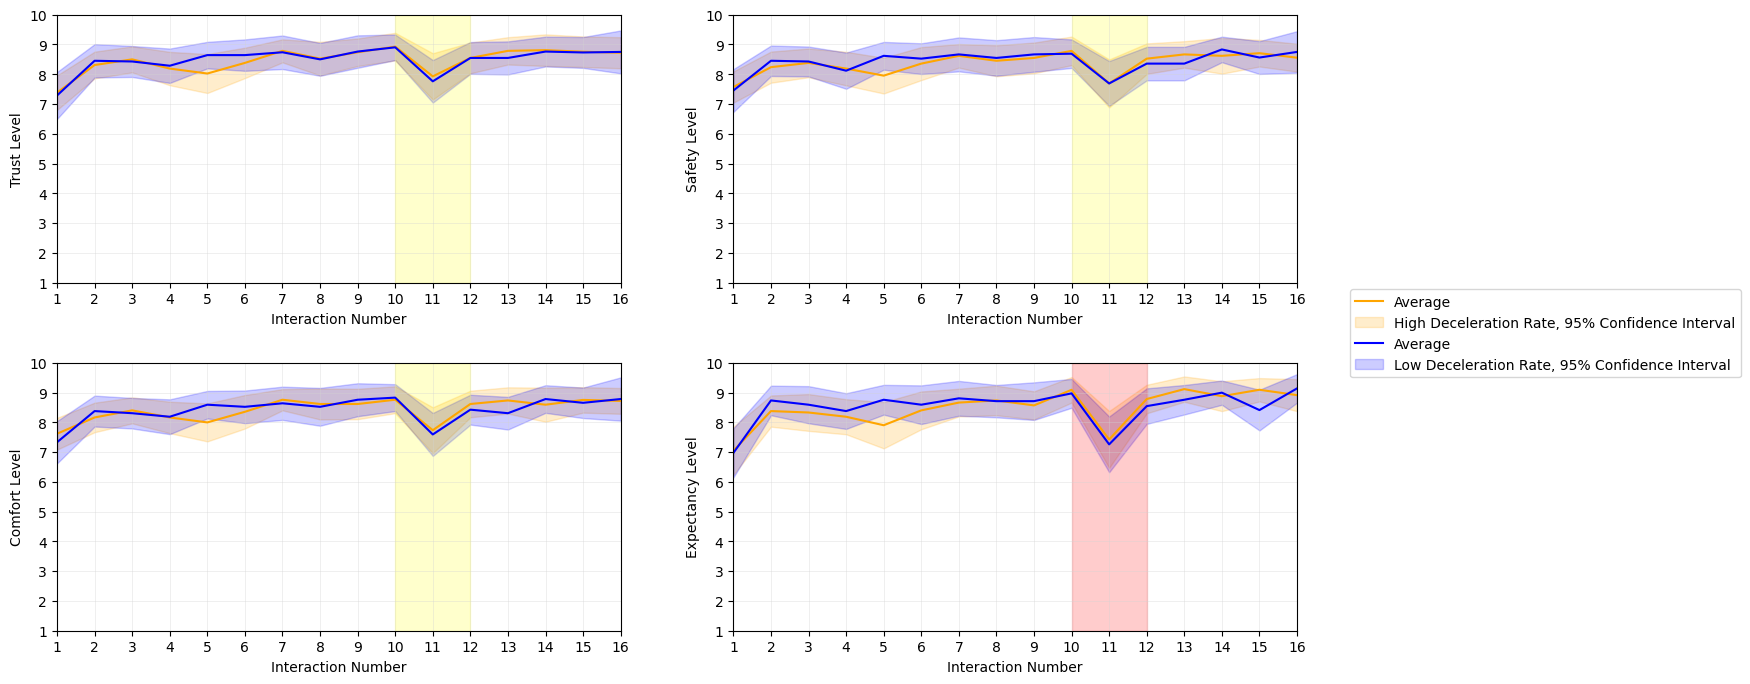

In [127]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex = False)

# Plot the mean line and confidence intervals for linearly interpolated trust
axs[0,0].plot(model_data_high_trust['Interaction No'], model_data_high_trust['Trust_mean'], label = 'Average', color = 'orange')
axs[0,0].fill_between(model_data_high_trust['Interaction No'], model_data_high_trust['Trust_ci_lower'], model_data_high_trust['Trust_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,0].plot(model_data_high_trust['Interaction No'], model_data_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0,0].fill_between(model_data_low_trust['Interaction No'], model_data_low_trust['Trust_ci_lower'], model_data_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,0].set_ylabel('Trust Level')
axs[0,0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,0].legend()
axs[0,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,0].set_ylim(1, 10)
axs[0,0].set_yticks(range(1, 11))
axs[0,0].set_xlim(1, 16)
axs[0,0].set_xticks(np.arange(1, 17, 1))
axs[0,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[0,1].plot(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_mean'], label = 'Average', color = 'orange')
axs[0,1].fill_between(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_ci_lower'], model_data_high_Safe['Safe_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,1].plot(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_mean'], label = 'Average', color = 'blue')
axs[0,1].fill_between(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_ci_lower'], model_data_low_Safe['Safe_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,1].set_ylabel('Safety Level')
axs[0,1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,1].legend()
axs[0,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,1].set_ylim(1, 10)
axs[0,1].set_yticks(range(1, 11))
axs[0,1].set_xlim(1, 16)
axs[0,1].set_xticks(range(1, 17))
axs[0,1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,0].plot(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_mean'], label = 'Average', color = 'orange')
axs[1,0].fill_between(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_ci_lower'], model_data_high_Comfort['Comfort_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,0].plot(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_mean'], label = 'Average', color = 'blue')
axs[1,0].fill_between(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_ci_lower'], model_data_low_Comfort['Comfort_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,0].set_ylabel('Comfort Level')
axs[1,0].set_xlabel('Interaction Number')
#axs[1,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,0].legend()
axs[1,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,0].set_ylim(1, 10)
axs[1,0].set_yticks(range(1, 11))
axs[1,0].set_xlim(1, 16)
axs[1,0].set_xticks(range(1, 17))
axs[1,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,1].plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
axs[1,1].fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,1].plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
axs[1,1].fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,1].set_ylabel('Expectancy Level')
axs[1,1].set_xlabel('Interaction Number')
#axs[1,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,1].legend()
axs[1,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,1].set_ylim(1, 10)
axs[1,1].set_yticks(range(1, 11))
axs[1,1].set_xlim(1, 16)
axs[1,1].set_xticks(range(1, 17))
# Define Inset Axes
#axin = inset_axes(axs[1,1], width = '17.5%', height = '50%', loc = 'lower right')
#axin.plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
#axin.fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Decelaration Rate, 95% Confidence Interval')
#axin.plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
#axin.fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Decelaration Rate, 95% Confidence Interval')
#axin.set_xlim(10, 12)
#axin.set_ylim(6,10)
#axs[1,1].indicate_inset_zoom(axin)
axs[1,1].axvspan(10, 12, color = 'red', alpha = 0.2)


plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Fill_Between_Plot_of_Dependent_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [128]:
high_first_low_last = [2, 4, 6, 8, 10, 12, 14, 16, 20, 22, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45]

low_first_high_last = [1, 3, 7, 9, 11, 12, 13, 15, 17, 19, 21, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46]

model_data_filtered_hfll = model_data[model_data.PID.isin(high_first_low_last)]

model_data_filtered_lfhl = model_data[model_data.PID.isin(low_first_high_last)]

In [129]:
# Calculate the confidence intervals for trust
# 1.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_trust = model_data_filtered_hfll.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci']
grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci']

# 1.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_trust = model_data_filtered_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci']
grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci']

# Calculate the confidence intervals for safety
# 2.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Safe = model_data_filtered_hfll.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Safe['Safe_count']-1)
grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_mean'] - grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci']
grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_mean'] + grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci']

# 2.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Safe = model_data_filtered_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_mean'] - grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci']
grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_mean'] + grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci']

# Calculate the confidence intervals for comfort
# 3.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Comfort = model_data_filtered_hfll.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_mean'] - grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci']
grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_mean'] + grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci']

# 3.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Comfort = model_data_filtered_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_mean'] - grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci']
grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_mean'] + grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci']

# Calculate the confidence intervals for comfort
# 4.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Expect = model_data_filtered_hfll.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Expect['Expect_count']-1)
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_mean'] - grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci']
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_mean'] + grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci']

# 4.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Expect = model_data_filtered_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_mean'] - grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci']
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_mean'] + grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci']

In [130]:
# 1.1. high-first-low-last
model_data_hfll_high_trust = grouped_for_fill_between_visualization_hfll_for_trust[grouped_for_fill_between_visualization_hfll_for_trust['DRate'] == 'High']
model_data_hfll_low_trust = grouped_for_fill_between_visualization_hfll_for_trust[grouped_for_fill_between_visualization_hfll_for_trust['DRate'] == 'Low']

# 1.2. low-first-high-last
model_data_lfhl_high_trust = grouped_for_fill_between_visualization_lfhl_for_trust[grouped_for_fill_between_visualization_lfhl_for_trust['DRate'] == 'High']
model_data_lfhl_low_trust = grouped_for_fill_between_visualization_lfhl_for_trust[grouped_for_fill_between_visualization_lfhl_for_trust['DRate'] == 'Low']


# 2.1. high-first-low-last
model_data_hfll_high_Safe = grouped_for_fill_between_visualization_hfll_for_Safe[grouped_for_fill_between_visualization_hfll_for_Safe['DRate'] == 'High']
model_data_hfll_low_Safe = grouped_for_fill_between_visualization_hfll_for_Safe[grouped_for_fill_between_visualization_hfll_for_Safe['DRate'] == 'Low']

# 2.2. low-first-high-last
model_data_lfhl_high_Safe = grouped_for_fill_between_visualization_lfhl_for_Safe[grouped_for_fill_between_visualization_lfhl_for_Safe['DRate'] == 'High']
model_data_lfhl_low_Safe = grouped_for_fill_between_visualization_lfhl_for_Safe[grouped_for_fill_between_visualization_lfhl_for_Safe['DRate'] == 'Low']


# 3.1. high-first-low-last
model_data_hfll_high_Comfort = grouped_for_fill_between_visualization_hfll_for_Comfort[grouped_for_fill_between_visualization_hfll_for_Comfort['DRate'] == 'High']
model_data_hfll_low_Comfort = grouped_for_fill_between_visualization_hfll_for_Comfort[grouped_for_fill_between_visualization_hfll_for_Comfort['DRate'] == 'Low']

# 3.2. low-first-high-last
model_data_lfhl_high_Comfort = grouped_for_fill_between_visualization_lfhl_for_Comfort[grouped_for_fill_between_visualization_lfhl_for_Comfort['DRate'] == 'High']
model_data_lfhl_low_Comfort = grouped_for_fill_between_visualization_lfhl_for_Comfort[grouped_for_fill_between_visualization_lfhl_for_Comfort['DRate'] == 'Low']


# 4.1. high-first-low-last
model_data_hfll_high_Expect = grouped_for_fill_between_visualization_hfll_for_Expect[grouped_for_fill_between_visualization_hfll_for_Expect['DRate'] == 'High']
model_data_hfll_low_Expect = grouped_for_fill_between_visualization_hfll_for_Expect[grouped_for_fill_between_visualization_hfll_for_Expect['DRate'] == 'Low']

# 4.2. low-first-high-last
model_data_lfhl_high_Expect = grouped_for_fill_between_visualization_lfhl_for_Expect[grouped_for_fill_between_visualization_lfhl_for_Expect['DRate'] == 'High']
model_data_lfhl_low_Expect = grouped_for_fill_between_visualization_lfhl_for_Expect[grouped_for_fill_between_visualization_lfhl_for_Expect['DRate'] == 'Low']

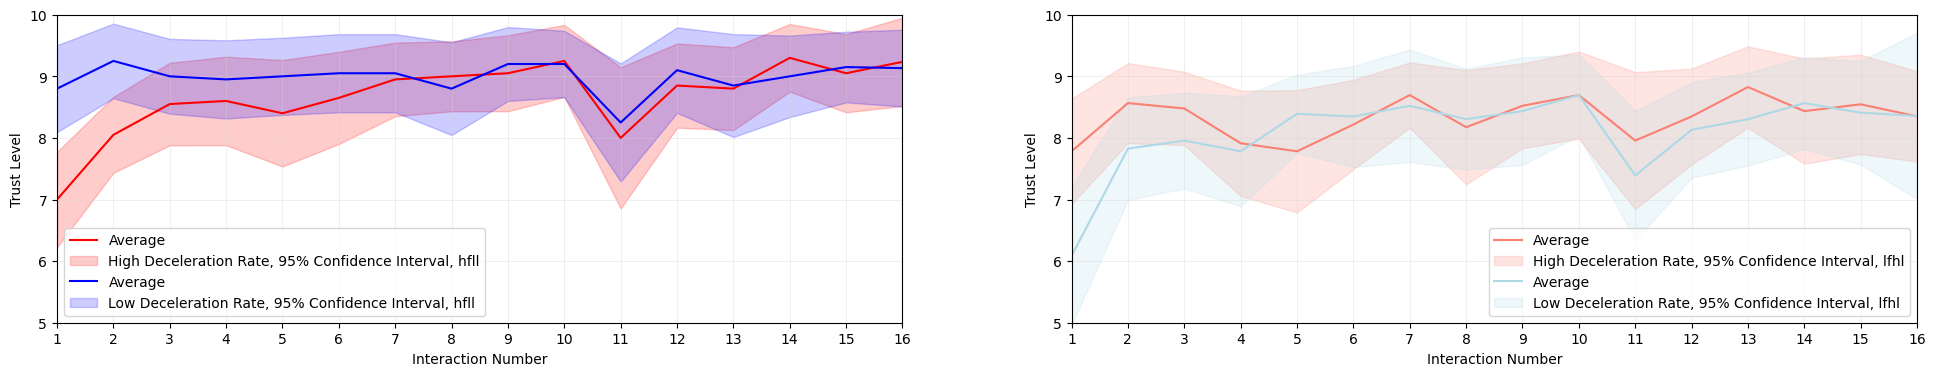

In [131]:
fig, axs = plt.subplots(1, 2, figsize=(24, 4), sharex = False)

# 1.1. high-first-low-last
axs[0].plot(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_mean'], label = 'Average', color = 'red')
axs[0].fill_between(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_ci_lower'], model_data_hfll_high_trust['Trust_ci_upper'], color='red', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval, hfll')

axs[0].plot(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0].fill_between(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_ci_lower'], model_data_hfll_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval, hfll')

axs[0].set_ylabel('Trust Level')
axs[0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
axs[0].legend()
axs[0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0].set_ylim(5, 10)
axs[0].set_yticks(range(5, 11))
axs[0].set_xlim(1, 16)
axs[0].set_xticks(np.arange(1, 17, 1))
#axs[0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

# 1.2. low-first-high-last
axs[1].plot(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_mean'], label = 'Average', color = 'salmon')
axs[1].fill_between(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_ci_lower'], model_data_lfhl_high_trust['Trust_ci_upper'], color='salmon', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval, lfhl')

axs[1].plot(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_mean'], label = 'Average', color = 'lightblue')
axs[1].fill_between(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_ci_lower'], model_data_lfhl_low_trust['Trust_ci_upper'], color='lightblue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval, lfhl')

axs[1].set_ylabel('Trust Level')
axs[1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
axs[1].legend()
axs[1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1].set_ylim(5, 10)
axs[1].set_yticks(range(5, 11))
axs[1].set_xlim(1, 16)
axs[1].set_xticks(range(1, 17))
#axs[1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
#plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Fill_Between_Plot_of_Trust_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

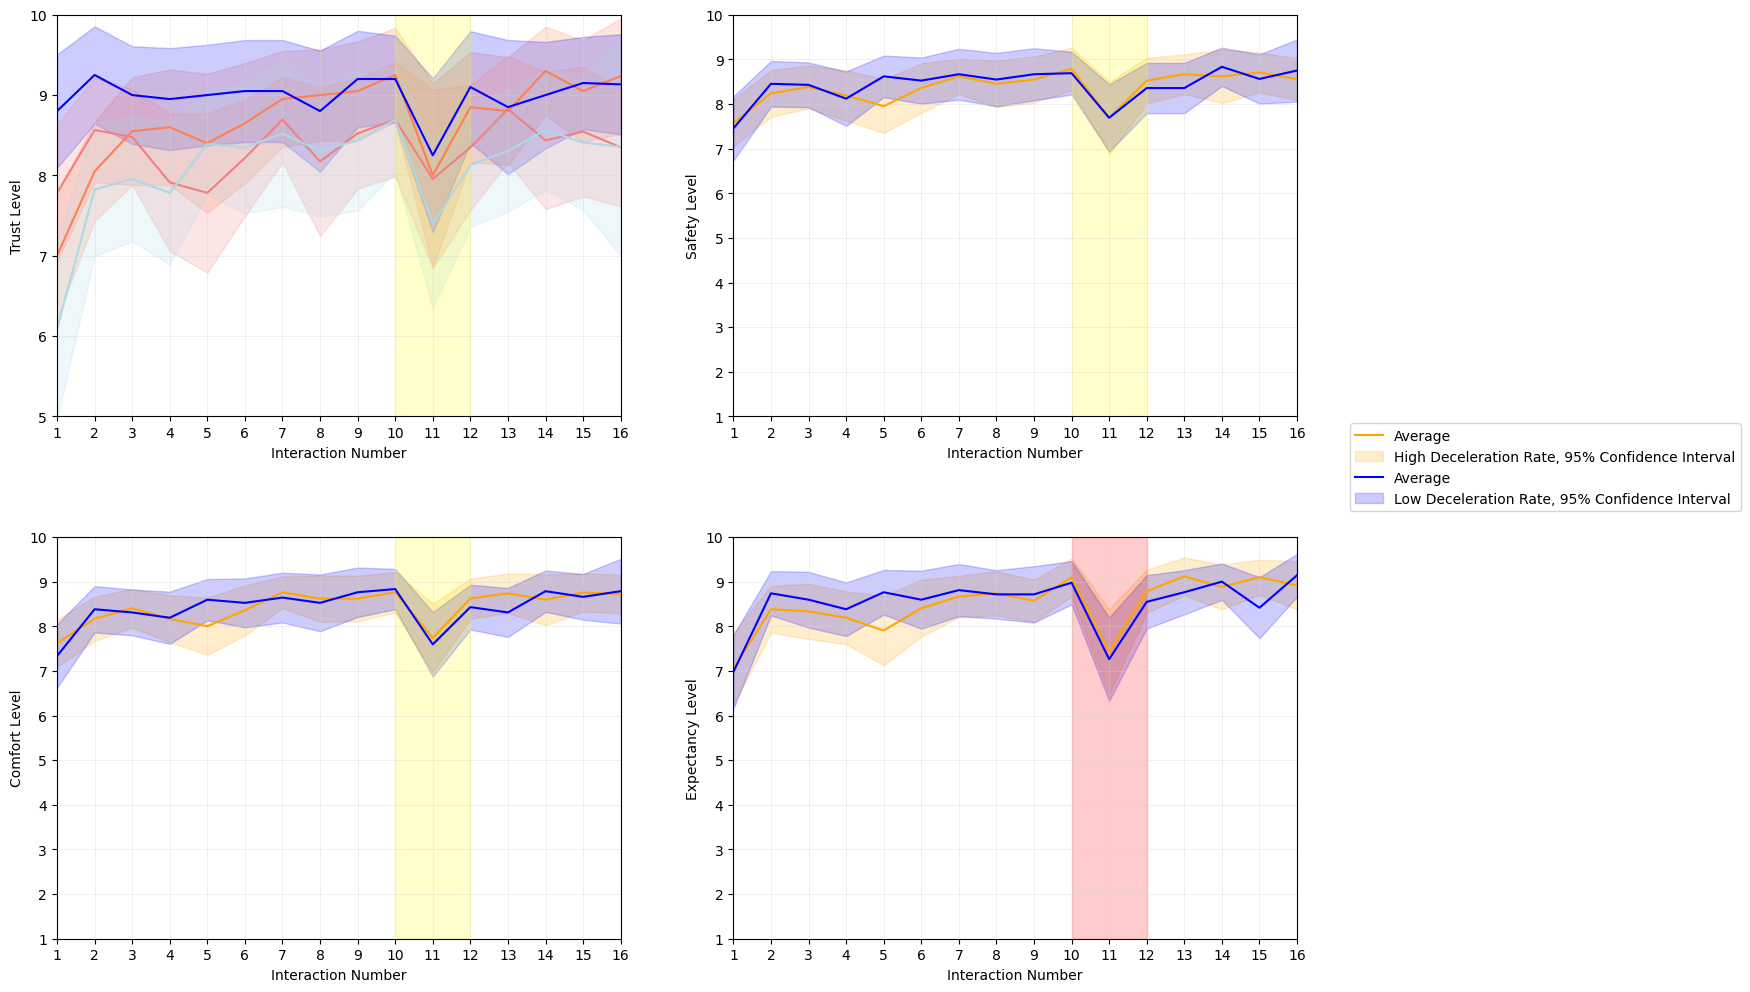

In [132]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex = False)

# 1.1. high-first-low-last
axs[0,0].plot(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_mean'], label = 'Average', color = 'coral')
axs[0,0].fill_between(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_ci_lower'], model_data_hfll_high_trust['Trust_ci_upper'], color='coral', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')

axs[0,0].plot(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0,0].fill_between(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_ci_lower'], model_data_hfll_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')

# 1.2. low-first-high-last
axs[0,0].plot(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_mean'], label = 'Average', color = 'lightcoral')
axs[0,0].fill_between(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_ci_lower'], model_data_lfhl_high_trust['Trust_ci_upper'], color='lightcoral', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')

axs[0,0].plot(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_mean'], label = 'Average', color = 'lightblue')
axs[0,0].fill_between(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_ci_lower'], model_data_lfhl_low_trust['Trust_ci_upper'], color='lightblue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')

axs[0,0].set_ylabel('Trust Level')
axs[0,0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,0].legend()
axs[0,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,0].set_ylim(5, 10)
axs[0,0].set_yticks(range(5, 11))
axs[0,0].set_xlim(1, 16)
axs[0,0].set_xticks(np.arange(1, 17, 1))
axs[0,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[0,1].plot(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_mean'], label = 'Average', color = 'orange')
axs[0,1].fill_between(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_ci_lower'], model_data_high_Safe['Safe_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,1].plot(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_mean'], label = 'Average', color = 'blue')
axs[0,1].fill_between(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_ci_lower'], model_data_low_Safe['Safe_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,1].set_ylabel('Safety Level')
axs[0,1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,1].legend()
axs[0,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,1].set_ylim(1, 10)
axs[0,1].set_yticks(range(1, 11))
axs[0,1].set_xlim(1, 16)
axs[0,1].set_xticks(range(1, 17))
axs[0,1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,0].plot(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_mean'], label = 'Average', color = 'orange')
axs[1,0].fill_between(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_ci_lower'], model_data_high_Comfort['Comfort_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,0].plot(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_mean'], label = 'Average', color = 'blue')
axs[1,0].fill_between(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_ci_lower'], model_data_low_Comfort['Comfort_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,0].set_ylabel('Comfort Level')
axs[1,0].set_xlabel('Interaction Number')
#axs[1,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,0].legend()
axs[1,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,0].set_ylim(1, 10)
axs[1,0].set_yticks(range(1, 11))
axs[1,0].set_xlim(1, 16)
axs[1,0].set_xticks(range(1, 17))
axs[1,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,1].plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
axs[1,1].fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,1].plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
axs[1,1].fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,1].set_ylabel('Expectancy Level')
axs[1,1].set_xlabel('Interaction Number')
#axs[1,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,1].legend()
axs[1,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,1].set_ylim(1, 10)
axs[1,1].set_yticks(range(1, 11))
axs[1,1].set_xlim(1, 16)
axs[1,1].set_xticks(range(1, 17))
# Define Inset Axes
#axin = inset_axes(axs[1,1], width = '17.5%', height = '50%', loc = 'lower right')
#axin.plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
#axin.fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Decelaration Rate, 95% Confidence Interval')
#axin.plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
#axin.fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Decelaration Rate, 95% Confidence Interval')
#axin.set_xlim(10, 12)
#axin.set_ylim(6,10)
#axs[1,1].indicate_inset_zoom(axin)
axs[1,1].axvspan(10, 12, color = 'red', alpha = 0.2)


plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Fill_Between_Plot_of_Dependent_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_34952\736619547.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(df[x_col], df[y_col], cmap=colormap, alpha=0.9,  edgecolor='black')


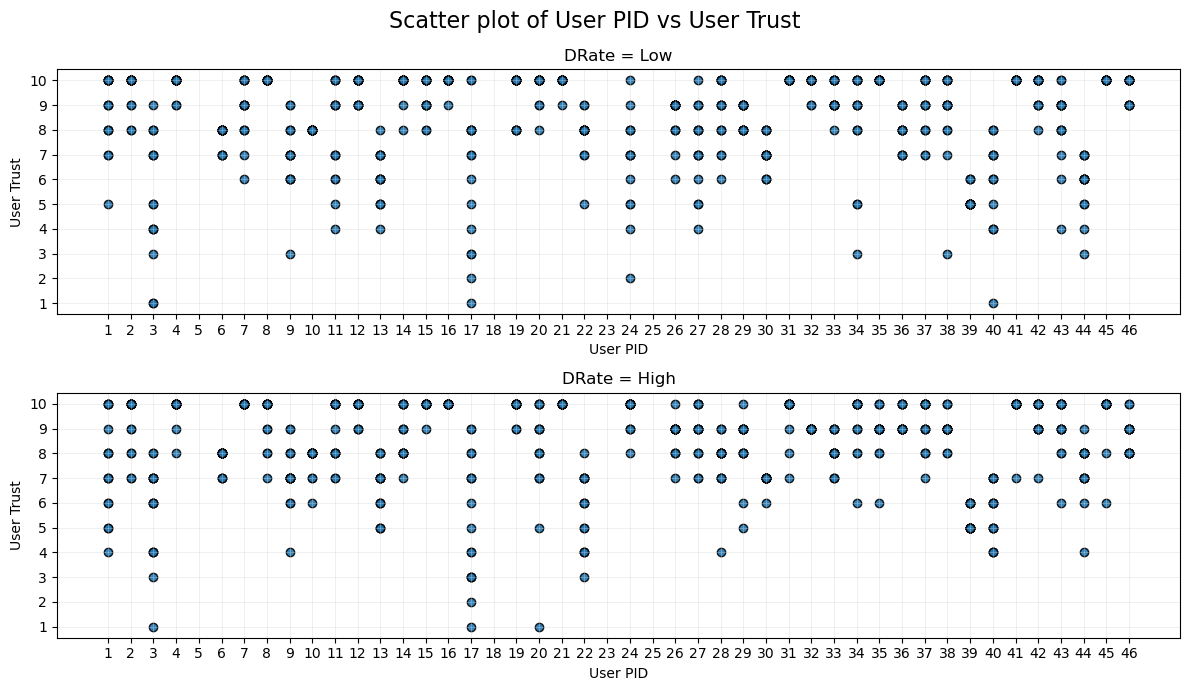

In [133]:
# Fixing random state for reproducibility
def create_scatter_plot(ax, df, x_col, y_col, colormap='viridis', title=None):

    scatter = ax.scatter(df[x_col], df[y_col], cmap=colormap, alpha=0.9,  edgecolor='black')
    
    # Adding lables and titles
    ax.set_xlabel('User PID')
    ax.set_ylabel('User Trust')
    if title:
        ax.set_title(title)
    else:
        ax.set_title('Scatter plot of User PID vs User trust')
    
    # Set x-axis and y-axis to increament by one unit
    x_min = model_data['PID'].min()
    x_max = model_data['PID'].max()
    ax.set_xticks(np.arange(x_min, x_max + 1, 1))
    
    y_min = model_data['Trust'].min()
    y_max = model_data['Trust'].max()
    ax.set_yticks(np.arange(y_min, y_max + 1, 1))
    
    # Add a light gray grid
    ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

model_data_low = model_data[model_data['DRate'] == 'Low']
model_data_high = model_data[model_data['DRate'] == 'High']

# Create subplots side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

create_scatter_plot(axes[0], model_data_low, 'PID', 'Trust', title = 'DRate = Low')
create_scatter_plot(axes[1], model_data_high, 'PID', 'Trust', title = 'DRate = High')

# Set an overall title
fig.suptitle('Scatter plot of User PID vs User Trust', fontsize=16)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

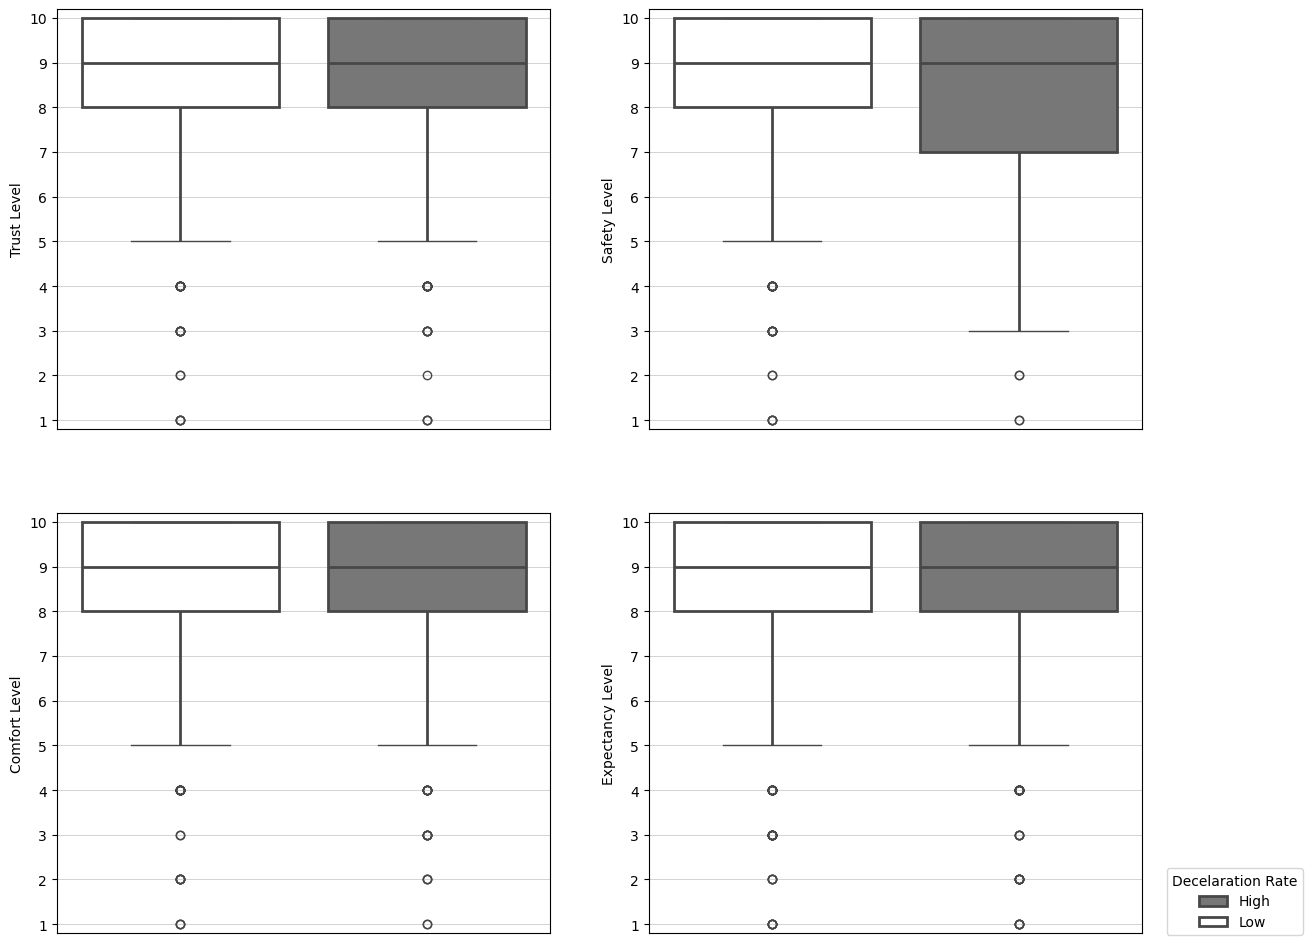

In [155]:
palette = sns.color_palette(['#777777', '#ffffff'], n_colors = model_data['DRate'].nunique())

fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Specify the order of the x values
custom_order = ['Low', 'High']

sns.boxplot(ax = axes[0, 0],
    x = 'DRate', y = 'Trust', 
    data = model_data, hue = 'DRate', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 10.2)
axes[0, 0].set_yticks(range(1, 11))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'DRate', y = 'Safe', 
    data = model_data, hue = 'DRate', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 10.2)
axes[0, 1].set_yticks(range(1, 11))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'DRate', y = 'Comfort', 
    data = model_data, hue = 'DRate', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 10.2)
axes[1, 0].set_yticks(range(1, 11))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'DRate', y = 'Expect', 
    data = model_data, hue = 'DRate', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 10.2)
axes[1, 1].set_yticks(range(1, 11))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

#hatches = ['/','\\', '|', '-','+']
#for i, box in enumerate(boxplot.patches):
#    box.set_edgecolor('black')
#    box.set_facecolor('lightgray')
#    box.set_hatch(hatches[i])

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'Decelaration Rate', bbox_to_anchor=(1.02, 0.17))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# plt.savefig(save_dir +'boxplots_of_four_independent_variables_based_on_decelaration_rate.png', bbox_inches='tight', pad_inches=0.1)

plt.show()

In [ ]:
# You need to show the intensity of each trust value chosen by the user. For instance, PID = 4 has less than ten unique trust values, so some of them has been picked up multiple times, thus the scatters need to be correlated by the frequency.
# Also, consider comparing the average, std, and mode among different users.

### With Respect to AGV Approaching Direction

In [ ]:
# Checking out unique values of AGVs approaching direction
model_data['AGV_Approaching'].unique()

In [ ]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'PID':'x', 'Trust':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (16, 8))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='red')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='green')

# Set x-axis and y-axis to increament by one unit
x_min = model_data['PID'].min()
x_max = model_data['PID'].max()
ax.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Trust Level among Different Users with Error Bars')
ax.set_xlabel('PID')
ax.set_ylabel('Trust Level')
ax.legend()


# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Comparison of Trust Level among Different Users with Error Bars_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Find a way that would show the min and max value of trust.

In [ ]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'AGVname':'x', 'Trust':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (16, 8))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='red')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='green')

# Set x-axis and y-axis to increament by one unit
x_min = model_data['AGVname'].min()
x_max = model_data['AGVname'].max()
ax.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Trust Levels among Different Interactions with Error Bars')
ax.set_xlabel('AGVname')
ax.set_ylabel('Trust Level')
ax.legend()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Comparison of Trust Levels among Different Interactions with Error Bars_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# You should highlight those pairs of AGVs that are having the same approaching direction.

In [ ]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'PID':'x', 'Expect':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (15, 5))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='blue')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='orange')

# Set x-axis and y-axis to increament by one unit
x_min = model_data['PID'].min()
x_max = model_data['PID'].max()
ax.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Expectancy Level among Different Users with Error Bars')
ax.set_xlabel('PID')
ax.set_ylabel('Expectancy Level')
ax.legend()

# Define the filename with timestamp
filename = 'Comparison of Expectancy Level among Different Users with Error Bars'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'AGVname':'x', 'Expect':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (15, 5))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='blue')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='orange')

# Set x-axis and y-axis to increament by one unit
x_min = model_data['AGVname'].min()
x_max = model_data['AGVname'].max()
ax.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Expectancy Level among Different Interactions with Error Bars')
ax.set_xlabel('AGVname')
ax.set_ylabel('Expectancy Level')
ax.legend()

plt.axvline(x=8.5, color='r', linestyle='--')

# Define the filename with timestamp
filename = 'Comparison of Expectancy Level among Different Interactions with Error Bars'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Filter data by DRate: We've already done that in the pervious kernels though:
model_data_high = model_data[model_data['DRate'] == 'High']
model_data_low = model_data[model_data['DRate'] == 'Low']


# Create pivot tables
pivot_high = model_data_high.pivot_table(index = 'PID', columns = 'AGVname', values='Trust', aggfunc = 'mean', fill_value=0)
pivot_low = model_data_low.pivot_table(index = 'PID', columns = 'AGVname', values='Trust', aggfunc = 'mean', fill_value=0)

# Extract relevant columns
# x_high = model_data_low['Trust']
# y_high = model_data_low['PID']
# x_low = model_data_high['Trust']
# y_low = model_data_high['PID']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

# Set x-axis and y-axis to increament by one unit
x_min = model_data['AGVname'].min()
x_max = model_data['AGVname'].max()
ax1.set_xticks(np.arange(x_min, x_max + 1, 1))
ax2.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['PID'].min()
y_max = model_data['PID'].max()
ax1.set_yticks(np.arange(y_min, y_max + 1, 1))
ax2.set_yticks(np.arange(y_min, y_max + 1, 1))

# Plot heatmap for the high category
sns.heatmap(pivot_high, ax = ax1, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax1.set_title('High Deceleration Rate')
ax1.set_xlabel('AGVname')
ax1.set_ylabel('User ID')

# Plot heatmap for the low category
sns.heatmap(pivot_low, ax = ax2, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax2.set_title('Low Deceleration Rate')
ax2.set_xlabel('AGVname')
ax2.set_ylabel('User ID')

# Add a single color bar for both heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
sns.heatmap(pivot_high, ax=ax1, cmap='RdYlGn', cbar_ax=cbar_ax, cbar_kws={'label': 'Trust Level'})

# Set the overall title
fig.suptitle('Heatmap of Trust for High vs. Low Deceleration Rate', fontsize = 14)

# Define the filename 
filename = 'Heatmap of Trust for Low vs High Deceleration Rate'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# plt.tight_layout()
plt.show()

In [ ]:
# Filter data by DRate: We've already done that in the pervious kernels though:
model_data_high = model_data[model_data['DRate'] == 'High']
model_data_low = model_data[model_data['DRate'] == 'Low']

# Create pivot tables
pivot_low = model_data_low.pivot_table(index = 'PID', columns = 'AGVname', values='Expect', aggfunc = 'mean', fill_value=0)
pivot_high = model_data_high.pivot_table(index = 'PID', columns = 'AGVname', values='Expect', aggfunc = 'mean', fill_value=0)

# Extract relevant columns
# x_high = model_data_low['Trust']
# y_high = model_data_low['PID']
# x_low = model_data_high['Trust']
# y_low = model_data_high['PID']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

# Set x-axis and y-axis to increament by one unit
x_min = model_data['AGVname'].min()
x_max = model_data['AGVname'].max()
ax1.set_xticks(np.arange(x_min, x_max + 1, 1))
ax2.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['PID'].min()
y_max = model_data['PID'].max()
#ax1.set_yticks(np.arange(y_min, y_max + 1, 1))
#ax2.set_yticks(np.arange(y_min, y_max + 1, 1))

# Plot heatmap for the high category
sns.heatmap(pivot_high, ax = ax1, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax1.set_title('High Deceleration Rate')
ax1.set_xlabel('AGVname')
ax1.set_ylabel('User ID')

# Plot heatmap for the low category
sns.heatmap(pivot_low, ax = ax2, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax2.set_title('Low Deceleration Rate')
ax2.set_xlabel('AGVname')
ax2.set_ylabel('User ID')
#ax2.grid(color='#222', linestyle='-', linewidth=0.01)

# Add a single color bar for both heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
sns.heatmap(pivot_high, ax=ax1, cmap='RdYlGn', cbar_ax=cbar_ax, cbar_kws={'label': 'Expectancy Level'})
# Set the overall title
fig.suptitle(r'Heatmap of Expectancy for High vs. Low Deceleration Rate', fontsize = 14)

# Define the filename 
filename = 'Heatmap of Expectancy for Low vs High Deceleration Rate'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# plt.tight_layout()
plt.show()

In [ ]:
# If you're trying to compare, you can make one heatmap, where each square in representing high and low ratings with a diagonal seperating them. 
# Or, you can have a transparency, where the high rating is towards red, and low ratings towards blue colormap, and if they overlay on each other they give you spectrum of purple.
# High - Low heatmap (absolute or +/-) to see the general trend in rates changing. Look to a way that is more intuitive.

In [135]:
model_data.AGV_Approaching.unique()

array(['North', 'South', 'Northeast', 'Northwest', 'East', 'Southwest',
       'West', 'Southeast'], dtype=object)

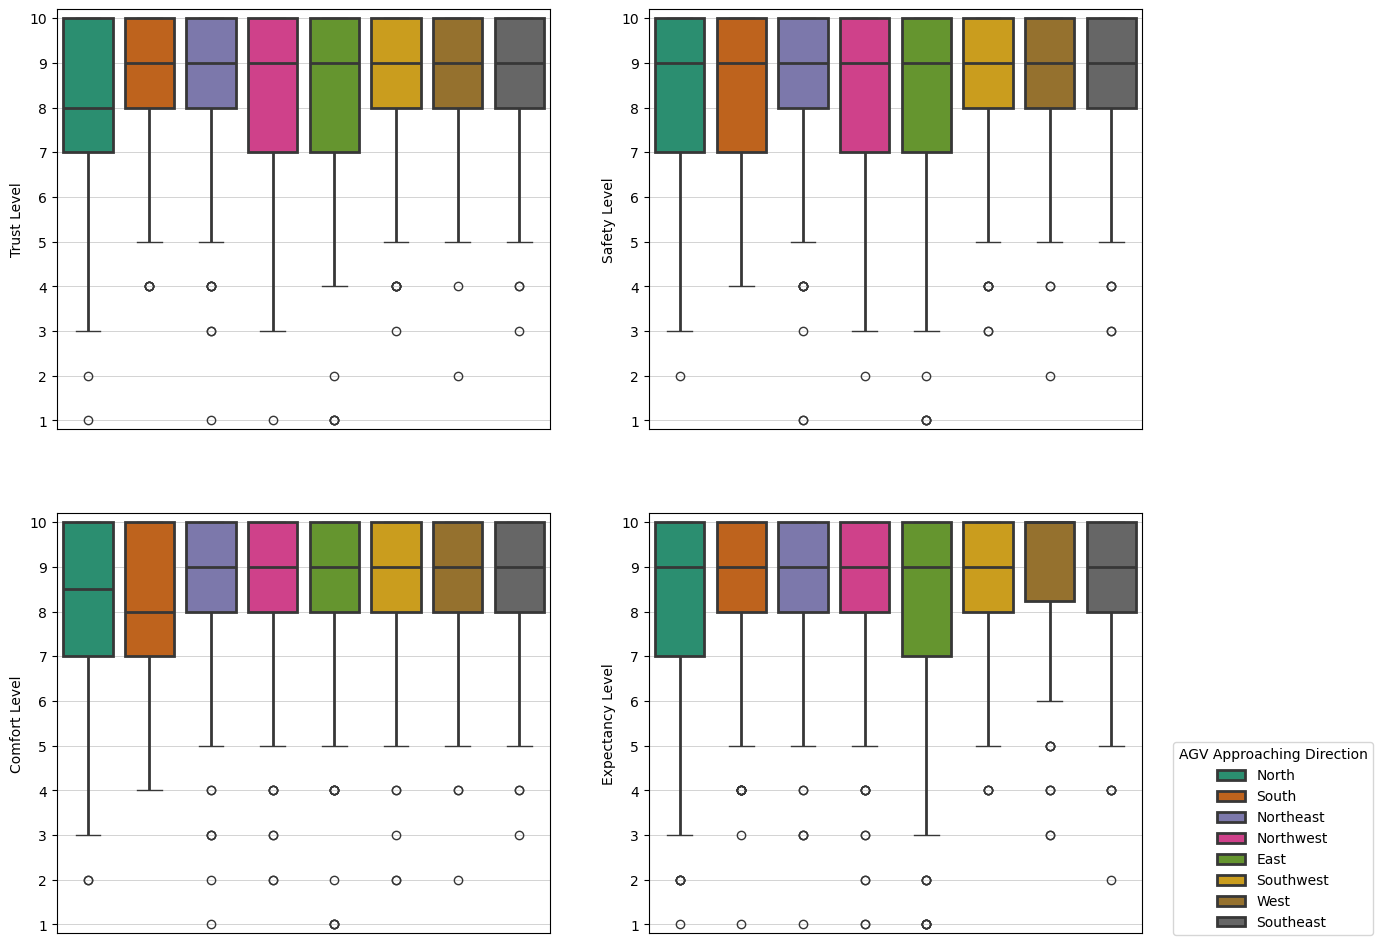

In [162]:
palette = sns.color_palette('Dark2', n_colors = model_data['AGV_Approaching'].nunique())

fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Specify the order of the x values
custom_order = ['North', 'South', 'Northeast', 'Northwest', 'East', 'Southwest',
       'West', 'Southeast']

sns.boxplot(ax = axes[0, 0],
    x = 'AGV_Approaching', y = 'Trust', 
    data = model_data, hue = 'AGV_Approaching', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 10.2)
axes[0, 0].set_yticks(range(1, 11))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'AGV_Approaching', y = 'Safe', 
    data = model_data, hue = 'AGV_Approaching', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 10.2)
axes[0, 1].set_yticks(range(1, 11))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'AGV_Approaching', y = 'Comfort', 
    data = model_data, hue = 'AGV_Approaching', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 10.2)
axes[1, 0].set_yticks(range(1, 11))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'AGV_Approaching', y = 'Expect', 
    data = model_data, hue = 'AGV_Approaching', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 10.2)
axes[1, 1].set_yticks(range(1, 11))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

#hatches = ['/','\\', '|', '-','+']
#for i, box in enumerate(boxplot.patches):
#    box.set_edgecolor('black')
#    box.set_facecolor('lightgray')
#    box.set_hatch(hatches[i])

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'AGV Approaching Direction', bbox_to_anchor=(1.07, 0.275))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_four_independent_variables_based_on_AGV_approaching_{timestamp}.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### With Respect to User_Trajectory

In [151]:
model_data.User_Trajectory.unique()

array(['Diagonal', 'Straight'], dtype=object)

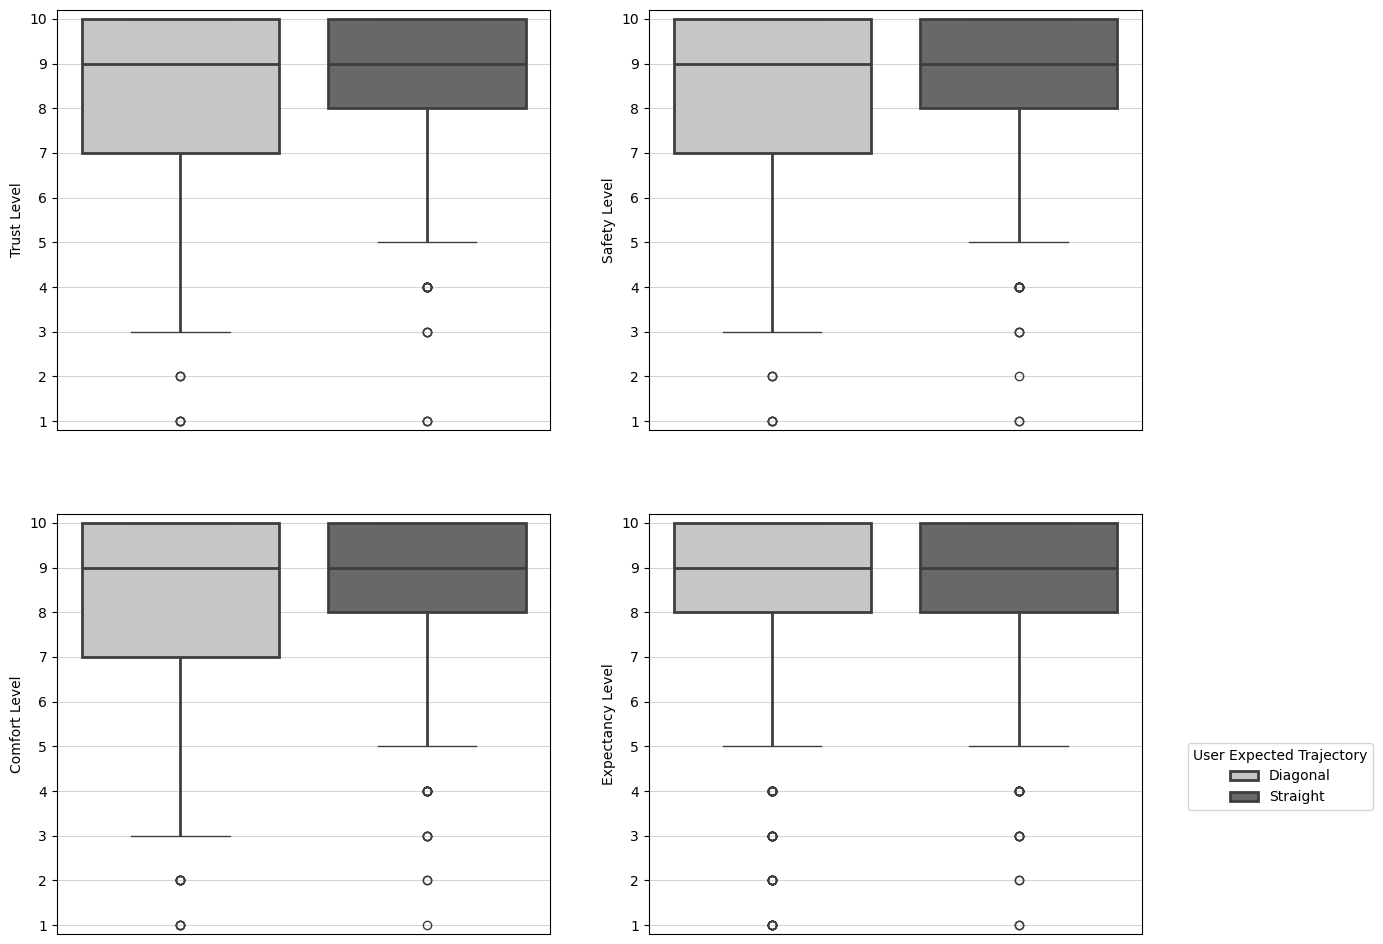

In [163]:
palette = sns.color_palette('Greys', n_colors = model_data['User_Trajectory'].nunique())

fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Specify the order of the x values
custom_order = ['Diagonal', 'Straight']

sns.boxplot(ax = axes[0, 0],
    x = 'User_Trajectory', y = 'Trust', 
    data = model_data, hue = 'User_Trajectory', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 10.2)
axes[0, 0].set_yticks(range(1, 11))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'User_Trajectory', y = 'Safe', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 10.2)
axes[0, 1].set_yticks(range(1, 11))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'User_Trajectory', y = 'Comfort', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 10.2)
axes[1, 0].set_yticks(range(1, 11))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'User_Trajectory', y = 'Expect', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 10.2)
axes[1, 1].set_yticks(range(1, 11))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

#hatches = ['/','\\', '|', '-','+']
#for i, box in enumerate(boxplot.patches):
#    box.set_edgecolor('black')
#    box.set_facecolor('lightgray')
#    box.set_hatch(hatches[i])

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'User Expected Trajectory', bbox_to_anchor=(1.07, 0.275))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_four_independent_variables_based_on_user_trajectory_{timestamp}.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### With Respect to AGV Approaching Direction:User_Trajectory

In [153]:
model_data.AGV_User_Combination.unique()

array(['North - Diagonal', 'South - Straight', 'South - Diagonal',
       'Northeast - Straight', 'Northwest - Straight',
       'Northwest - Diagonal', 'East - Straight', 'Southwest - Diagonal',
       'Northeast - Diagonal', 'West - Straight', 'East - Diagonal',
       'Southeast - Straight', 'Southwest - Straight',
       'Southeast - Diagonal', 'North - Straight', 'West - Diagonal'],
      dtype=object)

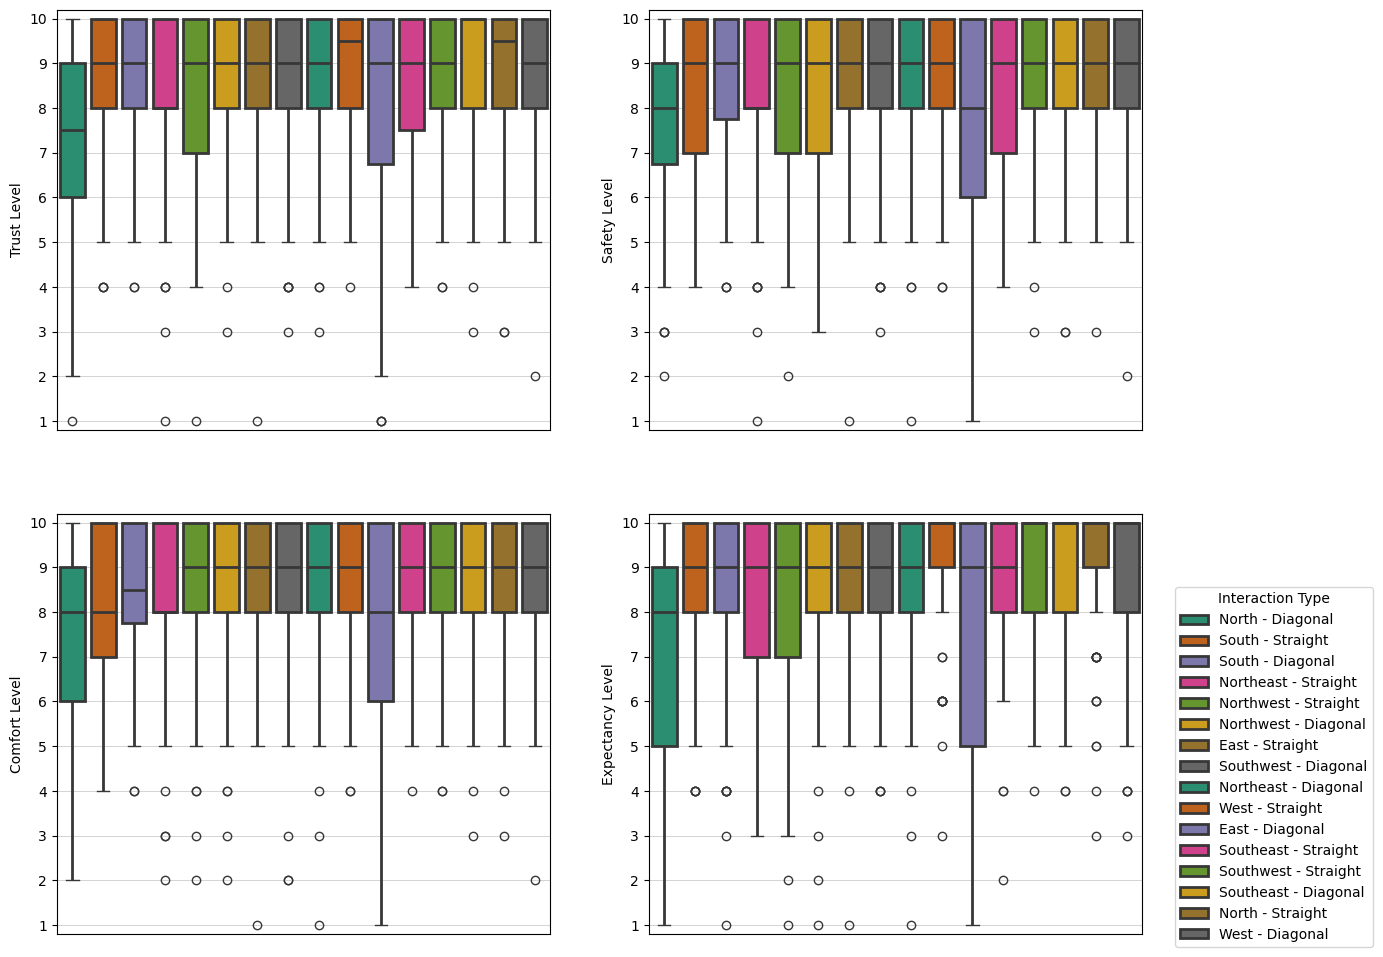

In [172]:
palette = sns.color_palette('Dark2', n_colors = model_data['AGV_User_Combination'].nunique())

fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Specify the order of the x values
custom_order = ['North - Diagonal', 'South - Straight', 'South - Diagonal',
       'Northeast - Straight', 'Northwest - Straight',
       'Northwest - Diagonal', 'East - Straight', 'Southwest - Diagonal',
       'Northeast - Diagonal', 'West - Straight', 'East - Diagonal',
       'Southeast - Straight', 'Southwest - Straight',
       'Southeast - Diagonal', 'North - Straight', 'West - Diagonal']

sns.boxplot(ax = axes[0, 0],
    x = 'AGV_User_Combination', y = 'Trust', 
    data = model_data, hue = 'AGV_User_Combination', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 10.2)
axes[0, 0].set_yticks(range(1, 11))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'AGV_User_Combination', y = 'Safe', 
    data = model_data, hue = 'AGV_User_Combination', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 10.2)
axes[0, 1].set_yticks(range(1, 11))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'AGV_User_Combination', y = 'Comfort', 
    data = model_data, hue = 'AGV_User_Combination', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 10.2)
axes[1, 0].set_yticks(range(1, 11))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'AGV_User_Combination', y = 'Expect', 
    data = model_data, hue = 'AGV_User_Combination', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 10.2)
axes[1, 1].set_yticks(range(1, 11))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

#hatches = ['/','\\', '|', '-','+']
#for i, box in enumerate(boxplot.patches):
#    box.set_edgecolor('black')
#    box.set_facecolor('lightgray')
#    box.set_hatch(hatches[i])

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'Interaction Type', bbox_to_anchor=(1.07, 0.405))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# generate a timestamp for the uniqueness 
# timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_four_independent_variables_based_on_AGV_User_Combination.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### Calculatin Trust before

In [193]:
high_first_low_last = [2, 4, 6, 8, 10, 12, 14, 16, 20, 22, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45]
low_first_high_last = [1, 3, 7, 9, 11, 12, 13, 15, 17, 19, 21, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46]

#model_data['Trust_before'] = np.nan

grouped_for_trust_before = model_data.groupby('PID')

for pid, group in grouped_for_trust_before:
    #print('In the first loop')
    group_high = group[group['DRate'] == 'High']
    group_low = group[group['DRate'] == 'Low']

    #checking to which group PID belongs to
    if pid in high_first_low_last:
        if not group_high.empty:
            model_data.loc[group_high.index, 'Trust_before'] = group_high['Trust'].shift(1)
            #print('In the first if')
            
        if not group_low.empty:
            model_data.loc[group_low.index[0], 'Trust_before'] = group_low['Trust1'].iloc[0]/10
            model_data.loc[group_low.index[1:], 'Trust_before'] = group_low['Trust'].shift(1)

    elif pid in low_first_high_last:
        if not group_low.empty:
            model_data.loc[group_low.index, 'Trust_before'] = group_low['Trust'].shift(1)

        if not group_high.empty:
            model_data.loc[group_high.index[0], 'Trust_before'] = group_high['Trust1'].iloc[0]/10
            model_data.loc[group_high.index[1:], 'Trust_before'] = group_high['Trust'].shift(1)

model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Assessment,Frechet_Distance,Gaze_on_AGV,User_Relative_Speed,User_Trajectory,AGV_Approaching,AGV_User_Combination,AGV_Path_Complexity,Interaction No,Trust_before
0,1,High,2024-5-3,14,28,53,1,15:2:48,15:3:38,219,...,1.812,NaN,0.063,137.683,Diagonal,North,North - Diagonal,Complex,1,4.9
1,1,High,2024-5-3,14,28,53,2,15:3:47,15:4:29,0,...,1.812,NaN,0.038,109.577,Straight,South,South - Straight,Straight,2,10.0
2,1,High,2024-5-3,14,28,53,3,15:4:37,15:5:34,268,...,1.812,NaN,0.069,131.592,Diagonal,South,South - Diagonal,Complex,3,10.0
3,1,High,2024-5-3,14,28,53,4,15:5:46,15:6:37,779,...,1.812,NaN,0.231,95.205,Straight,Northeast,Northeast - Straight,Complex,4,10.0
4,1,High,2024-5-3,14,28,53,5,15:6:41,15:7:44,868,...,1.812,NaN,0.234,185.999,Straight,Northwest,Northwest - Straight,Complex,5,7.0


In [194]:
North_Diagonal = model_data.loc[model_data['AGV_User_Combination'] == 'North - Diagonal', 'Trust_before'].values
print(North_Diagonal)

[4.9 nan nan 7.3 6.3 nan nan 8.5 nan 5.9 8.1 nan nan 8.3 4.2 nan nan 8.7
 6.6 nan nan 7.6 5.1 nan nan 8.2 7.6 nan nan 8.  5.3 nan 9.3 nan nan 7.7
 8.3 nan nan 6.4 5.  nan 7.5 nan nan 5.3 6.8 nan nan 6.6 4.8 nan nan 9.2
 8.3 nan nan 8.  8.1 nan nan 8.4 8.2 nan nan 6.  7.6 nan nan 4.8 5.7 nan
 nan 8.  8.5 nan nan 5.7 5.8 nan nan 9.7 7.7 nan]


[4.9 7.3 6.3 8.5 5.9 8.1 8.3 4.2 8.7 6.6 7.6 5.1 8.2 7.6 8.  5.3 9.3 7.7
 8.3 6.4 5.  7.5 5.3 6.8 6.6 4.8 9.2 8.3 8.  8.1 8.4 8.2 6.  7.6 4.8 5.7
 8.  8.5 5.7 5.8 9.7 7.7]


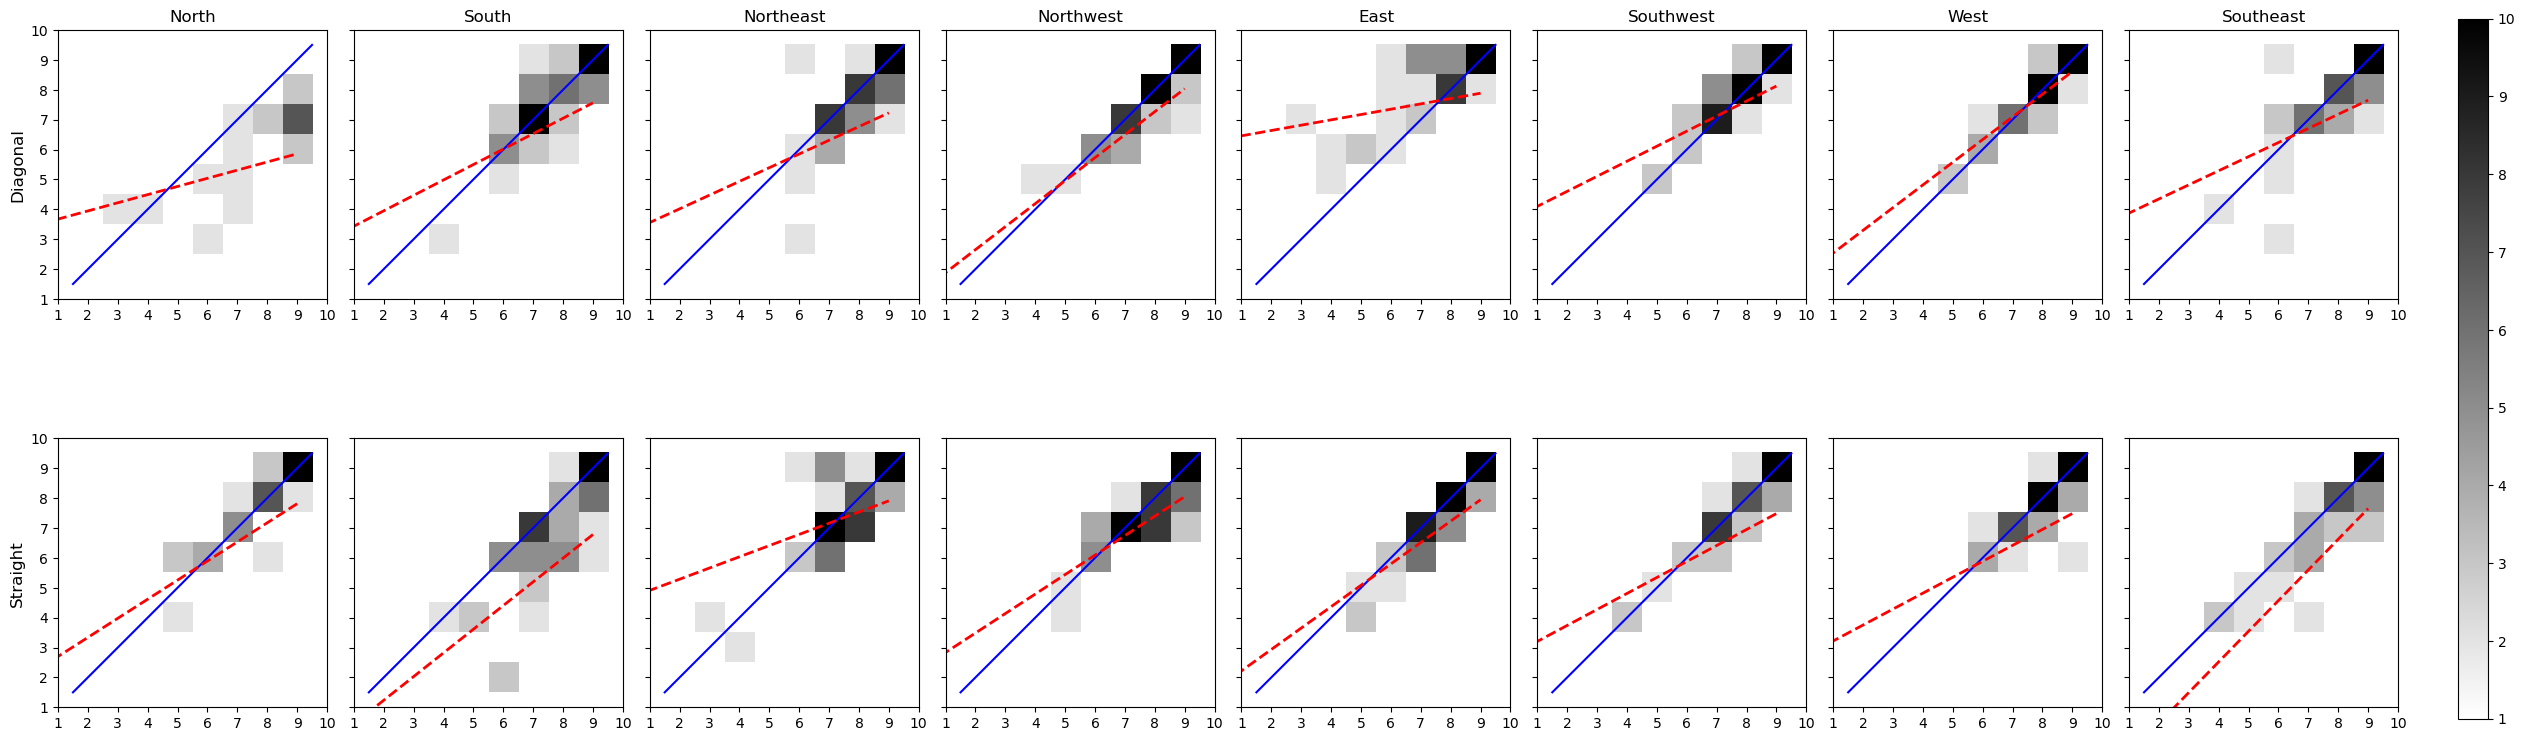

In [195]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize

model_data_for_transition_matrix = model_data.copy() 

# We only want the records that their 'Trust_before' is not Nan
model_data_for_transition_matrix = model_data_for_transition_matrix[model_data_for_transition_matrix['Trust_before'].notna()]
print(model_data_for_transition_matrix.loc[model_data_for_transition_matrix['AGV_User_Combination'] == 'North - Diagonal', 'Trust_before'].values)

# Extract unique AGVname and User Trajectory values
unique_agv = model_data_for_transition_matrix['AGV_Approaching'].unique()
unique_trajectory = model_data_for_transition_matrix['User_Trajectory'].unique()

# Intializing the transition matrix 
transition_matrices = {agv: {traj: np.zeros((10, 10)) for traj in unique_trajectory} for agv in unique_agv}

for idx, row in model_data_for_transition_matrix.iterrows():
    agv = row['AGV_Approaching']
    traj = row['User_Trajectory']
    trust_before = int(row['Trust_before']) - 1
    trust_after = int(row['Trust']) - 1

    transition_matrices[agv][traj][trust_before, trust_after] += 1

fig, axes = plt.subplots(len(unique_trajectory), len(unique_agv), figsize=(30, 28))

cbar_ax = fig.add_axes([0.9, 0.05, 0.01, 0.25])

for i, traj in enumerate(unique_trajectory):
    for j, agv in enumerate(unique_agv):
        ax = axes[i, j]

        matrix_size = transition_matrices[agv][traj].shape[0]
        ax.plot([1.5, matrix_size - 0.5], [1.5, matrix_size - 0.5], color='blue', linestyle='-', linewidth=1.5)
        #ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.5)

        # Linear Regression Line
        x = np.arange(matrix_size)
        y = np.arange(matrix_size)
        X, Y = np.meshgrid(x, y)
        X_flat = X.flatten()
        Y_flat = Y.flatten()
        values = transition_matrices[agv][traj].flatten()

        # Filter out zero values for fitting
        mask = values > 0
        X_flat_filtered = X_flat[mask]
        Y_flat_filtered = Y_flat[mask]
        values_filtered = values[mask]

        if len(X_flat_filtered) > 1:
            coeffs = np.polyfit(X_flat_filtered, Y_flat_filtered, 1)
            poly = np.poly1d(coeffs)

            # Calculate regression line
            y_reg = poly(x)
            ax.plot(x, y_reg, color='red', linestyle='--', linewidth=2)
            
        img = ax.matshow(transition_matrices[agv][traj], cmap = 'binary', norm=Normalize(vmin=1, vmax=10))

        # Flip y and x axis
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')
        #ax.set_xticks(range(1, 10.1))
        ax.set_xlim(1, 10)
        #ax.set_xticklabels('12345678910')

        # Hide x-axis
        if i != len(unique_trajectory) - 1:
            ax.set_xlim(1, 9)
            #ax.set_xticklabels([])
            #ax.set_xticks(range(1, 10))
                     

        # Hide y-axis
        if j != 0:
            ax.set_ylim(1, 10)
            ax.set_yticklabels([])
            #ax.set_yticks(range(1, 10))       

        if i == 0:
            ax.set_title(agv, fontsize = 12)
            ax.set_xlim(1, 10)
        if j == 0:
            ax.set_ylabel(traj, fontsize = 12)
            ax.set_ylim(1, 10)


fig.colorbar(img, cax=cbar_ax, shrink=1, pad=0.2)

plt.subplots_adjust(left=0.1, right=0.88, top = 0.3, bottom=0.05, wspace=0.1, hspace=0.4)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'transition_matrices_{timestamp}.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Display the plot
# plt.tight_layout(rect=[0,0,1,1])
plt.show()

In [196]:
model_data_for_transition_matrix.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Assessment,Frechet_Distance,Gaze_on_AGV,User_Relative_Speed,User_Trajectory,AGV_Approaching,AGV_User_Combination,AGV_Path_Complexity,Interaction No,Trust_before
0,1,High,2024-5-3,14,28,53,1,15:2:48,15:3:38,219,...,1.812,NaN,0.063,137.683,Diagonal,North,North - Diagonal,Complex,1,4.9
1,1,High,2024-5-3,14,28,53,2,15:3:47,15:4:29,0,...,1.812,NaN,0.038,109.577,Straight,South,South - Straight,Straight,2,10.0
2,1,High,2024-5-3,14,28,53,3,15:4:37,15:5:34,268,...,1.812,NaN,0.069,131.592,Diagonal,South,South - Diagonal,Complex,3,10.0
3,1,High,2024-5-3,14,28,53,4,15:5:46,15:6:37,779,...,1.812,NaN,0.231,95.205,Straight,Northeast,Northeast - Straight,Complex,4,10.0
4,1,High,2024-5-3,14,28,53,5,15:6:41,15:7:44,868,...,1.812,NaN,0.234,185.999,Straight,Northwest,Northwest - Straight,Complex,5,7.0


In [197]:
model_data_for_transition_matrix.to_csv('model_data_for_transition_matrix.csv', index=False)

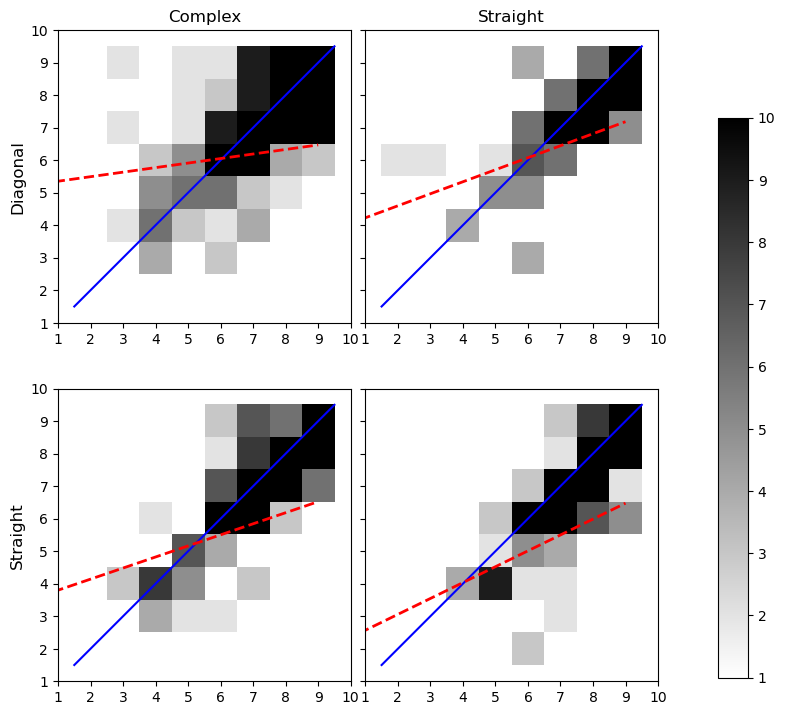

In [214]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize

model_data_for_transition_matrix = model_data.copy() 

# We only want the records that their 'Trust_before' is not Nan
model_data_for_transition_matrix = model_data_for_transition_matrix[model_data_for_transition_matrix['Trust_before'].notna()]

# Extract unique AGVname and User Trajectory values
unique_agv = model_data_for_transition_matrix['AGV_Path_Complexity'].unique()
unique_trajectory = model_data_for_transition_matrix['User_Trajectory'].unique()

# Intializing the transition matrix 
transition_matrices = {agv: {traj: np.zeros((10, 10)) for traj in unique_trajectory} for agv in unique_agv}

for idx, row in model_data_for_transition_matrix.iterrows():
    agv = row['AGV_Path_Complexity']
    traj = row['User_Trajectory']
    trust_before = int(row['Trust_before']) - 1
    trust_after = int(row['Trust']) - 1

    transition_matrices[agv][traj][trust_before, trust_after] += 1

fig, axes = plt.subplots(len(unique_trajectory), len(unique_agv), figsize=(30, 28))

cbar_ax = fig.add_axes([0.32, 0.06, 0.01, 0.20])

for i, traj in enumerate(unique_trajectory):
    for j, agv in enumerate(unique_agv):
        ax = axes[i, j]

        matrix_size = transition_matrices[agv][traj].shape[0]
        ax.plot([1.5, matrix_size - 0.5], [1.5, matrix_size - 0.5], color='blue', linestyle='-', linewidth=1.5)
        #ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.5)

        # Linear Regression Line
        x = np.arange(matrix_size)
        y = np.arange(matrix_size)
        X, Y = np.meshgrid(x, y)
        X_flat = X.flatten()
        Y_flat = Y.flatten()
        values = transition_matrices[agv][traj].flatten()

        # Filter out zero values for fitting
        mask = values > 0
        X_flat_filtered = X_flat[mask]
        Y_flat_filtered = Y_flat[mask]
        values_filtered = values[mask]

        if len(X_flat_filtered) > 1:
            coeffs = np.polyfit(X_flat_filtered, Y_flat_filtered, 1)
            poly = np.poly1d(coeffs)

            # Calculate regression line
            y_reg = poly(x)
            ax.plot(x, y_reg, color='red', linestyle='--', linewidth=2)
            
        img = ax.matshow(transition_matrices[agv][traj], cmap = 'binary', norm=Normalize(vmin=1, vmax=10))

        # Flip y and x axis
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')
        #ax.set_xticks(range(1, 10.1))
        ax.set_xlim(1, 10)
        #ax.set_xticklabels('12345678910')

        # Hide x-axis
        if i != len(unique_trajectory) - 1:
            ax.set_xlim(1, 9)
            #ax.set_xticklabels([])
            #ax.set_xticks(range(1, 10))
                     

        # Hide y-axis
        if j != 0:
            ax.set_ylim(1, 10)
            ax.set_yticklabels([])
            #ax.set_yticks(range(1, 10))       

        if i == 0:
            ax.set_title(agv, fontsize = 12)
            ax.set_xlim(1, 10)
        if j == 0:
            ax.set_ylabel(traj, fontsize = 12)
            ax.set_ylim(1, 10)


fig.colorbar(img, cax=cbar_ax, shrink=1, pad=0.2)

plt.subplots_adjust(left=0.1, right=0.3, top = 0.3, bottom=0.05, wspace=0.05, hspace=0.05)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'transition_matrices_with_agv_path_complexity_{timestamp}.png'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Display the plot
# plt.tight_layout(rect=[0,0,1,1])
plt.show()

## Inferential Statistics

### Summary Statistics

In [ ]:
pd.options.display.float_format = '{:.3g}'.format

summary_stats = model_data_filtered.groupby(['DRate', 'AGVname']).agg({
    'Trust': ['min', 'median','mean', 'max','std'],
    'Safe': ['min', 'median','mean', 'max','std'],
    'Comfort': ['min', 'median','mean', 'max','std'],
    'Expect': ['min', 'median','mean', 'max','std'],
})

summary_stats = summary_stats.applymap(lambda x: '{:.3g}'.format(x))

summary_stats

In [ ]:
summary_stats.to_csv('summary_statistics_for_16_participants.csv', index = True)

### ANOVA, using statsmodels library

In [ ]:
# Fit the model
model = smf.ols('Trust ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching'
                , data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Trust Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [ ]:
# Fit the model
model = smf.ols('Safe ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Safety Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [ ]:
# Fit the model
model = smf.ols('Comfort ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Comfort Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [ ]:
# Fit the model
model = smf.ols('Expect ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Expectancy Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### ANOVA, using pingouin library

In [ ]:
anova_table = pg.anova(dv = 'Trust', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

In [ ]:
anova_table = pg.anova(dv = 'Safe', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

In [ ]:
anova_table = pg.anova(dv = 'Comfort', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

In [ ]:
anova_table = pg.anova(dv = 'Expect', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

## t-test

In [ ]:
summary, results = rp.ttest(group1=model_data['Trust'][model_data['DRate'] == 'Low'],
                            group1_name='Low Deceleration Rate', 
                            group2=model_data['Trust'][model_data['DRate'] == 'High'],
                            group2_name='High Deceleration Rate', 
                            equal_variances=True, 
                            paired=False)
summary, results

In [ ]:
summary, results = rp.ttest(group1=model_data['Expect'][model_data['DRate'] == 'Low'],
                            group1_name='Low Deceleration Rate', 
                            group2=model_data['Expect'][model_data['DRate'] == 'High'],
                            group2_name='High Deceleration Rate', 
                            equal_variances=True, 
                            paired=False)
summary, results

## t-test between each pair of DVs

In [175]:
group_t = model_data['Trust']
group_e = model_data['Expect']
group_s = model_data['Safe']
group_c = model_data['Comfort']

In [176]:
t_stat, p_value = ttest_ind(group_t, group_e)

print(f"T-statistics between group_t and group_e: {t_stat:.2f}")
print(f"P-value between group_t and group_e: {p_value:.2f}")

T-statistics between group_t and group_e: -0.32
P-value between group_t and group_e: 0.75


In [177]:
t_stat, p_value = ttest_ind(group_t, group_s)

print(f"T-statistics between group_t and group_s: {t_stat:.2f}")
print(f"P-value between group_t and group_s: {p_value:.2f}")

T-statistics between group_t and group_s: 1.13
P-value between group_t and group_s: 0.26


In [178]:
t_stat, p_value = ttest_ind(group_t, group_c)

print(f"T-statistics between group_t and group_c: {t_stat:.2f}")
print(f"P-value between group_t and group_c: {p_value:.2f}")

T-statistics between group_t and group_c: 0.82
P-value between group_t and group_c: 0.41


In [179]:
t_stat, p_value = ttest_ind(group_e, group_s)

print(f"T-statistics between group_e and group_s: {t_stat:.2f}")
print(f"P-value between group_e and group_s: {p_value:.2f}")

T-statistics between group_e and group_s: 1.38
P-value between group_e and group_s: 0.17


In [180]:
t_stat, p_value = ttest_ind(group_e, group_c)

print(f"T-statistics between group_e and group_c: {t_stat:.2f}")
print(f"P-value between group_e and group_c: {p_value:.2f}")

T-statistics between group_e and group_c: 1.09
P-value between group_e and group_c: 0.27


In [181]:
t_stat, p_value = ttest_ind(group_s, group_c)

print(f"T-statistics between group_s and group_c: {t_stat:.2f}")
print(f"P-value between group_s and group_c: {p_value:.2f}")

T-statistics between group_s and group_c: -0.32
P-value between group_s and group_c: 0.75


## Calculating the Sample Size and Effect Size
Calculating the sample size for minimum detectable effect

In [ ]:
trust_data_low = model_data['Trust'][model_data['DRate'] == 'Low']
trust_data_high = model_data['Trust'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(trust_data_low), np.mean(trust_data_high)
std_low, std_high = np.std(trust_data_low, ddof=1), np.std(trust_data_high, ddof=1)
len_low, len_high = len(trust_data_low), len(trust_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Trust":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Trust":', sample_size)

In [ ]:
expect_data_low = model_data['Expect'][model_data['DRate'] == 'Low']
expect_data_high = model_data['Expect'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(expect_data_low), np.mean(expect_data_high)
std_low, std_high = np.std(expect_data_low, ddof=1), np.std(expect_data_high, ddof=1)
len_low, len_high = len(expect_data_low), len(expect_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Expect":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Expect":', sample_size)

In [ ]:
safe_data_low = model_data['Safe'][model_data['DRate'] == 'Low']
safe_data_high = model_data['Safe'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(safe_data_low), np.mean(safe_data_high)
std_low, std_high = np.std(safe_data_low, ddof=1), np.std(safe_data_high, ddof=1)
len_low, len_high = len(safe_data_low), len(safe_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Safe":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Safe":', sample_size)

In [ ]:
comfort_data_low = model_data['Comfort'][model_data['DRate'] == 'Low']
comfort_data_high = model_data['Comfort'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(comfort_data_low), np.mean(comfort_data_high)
std_low, std_high = np.std(comfort_data_low, ddof=1), np.std(comfort_data_high, ddof=1)
len_low, len_high = len(comfort_data_low), len(comfort_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Comfort":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Comfort":', sample_size)

## Feature Selection
#### Below, is the list of all features:
**'PID'**: Categorical<br>
**'Age'**: Numerical<br>
**'Gender'**: Categorical<br>
**'Ethnicity'**: Categorical<br>
**'GamingFrequency'**: Categorical<br>
**'VRExperience'**: Categorical<br>
**'VRHeadsetExperience'**: Categorical<br>
**'AGVInteraction'**: Categorical<br>
**'PerfectAutomation'**: Numerical<br>
**'TrustPropensity'**: Numerical<br>
**'AutomationExperience'**: Numerical<br>
**'AGVname'**: Categorical<br>
**'User_Relative_Speed'**: Numerical<br>
**'Frechet_Distance'**: Numerical<br>
**'AGV_Approaching'**: Categorical<br>
**'User_Trajectory'**: Categorical<br>
**'Gaze_on_AGV'**: Numerical<br>
**'Cross_First'**: Categorical<br>
**'DRate'**: Categorical<br>
**'date'**: Numerical<br>
**'hr'**: Numerical<br>
**'min'**: Numerical<br>
**'s'**: Numerical<br>
**'StartTime'**: Numerical<br>
**'EndTime'**: Numerical<br>
**'GazeDuration'**: Numerical<br>
**'mean_dist'**: Numerical<br>
**'min_dist'**: Numerical<br>
**'max_dist'**: Numerical<br>
**'std_dist'**: Numerical<br>
**'mean_agv_spd'**: Numerical<br>
**'min_agv_spd'**: Numerical<br>
**'max_agv_spd'**: Numerical<br>
**'std_spd'**: Numerical<br>
**'task'**: Categorical<br>
**'Trust'**: Numerical<br>
**'Safe'**: Numerical<br>
**'Comfort'**: Numerical<br>
**'Expect'**: Num
rical<br>
**'Trust1'**: Numerical<br> N
**'Trust2'**: Numerical<br>
**'MWL'**:umerical<br>
**'Assessment'**: Numerical


In [ ]:
# Get dummy variables for categorical features. If 'Cross_First', and 'Frechet_Distance' were filled out, don't drop them
model_data_with_dummies = pd.get_dummies(model_data.drop(columns=['Cross_First','date','StartTime','EndTime']), columns=['PID','Gender','Ethnicity','GamingFrequency','VRExperience','VRHeadsetExperience','AGVInteraction','AGVname','AGV_Approaching','User_Trajectory','DRate','task'], drop_first=True)
model_data_with_dummies.head()

In [ ]:
X = model_data_with_dummies.drop(columns=['Trust','Safe','Comfort','Expect'])
y = model_data_with_dummies.Trust

cv = KFold(n_splits=10, random_state=0, shuffle=True)
classifier_pipeline = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10))
y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)

print("RMSE:" + str(round(sqrt(mean_squared_error(y, y_pred)),2)))
print("R_squared:" + str(round(sqrt(r2_score(y, y_pred)),2)))

### Filter Features by Variance

In [ ]:
# We can consider the features with high variance where they highly change in their values

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

model_data_with_dummies.var().sort_values(ascending=False)

In [ ]:
# Drop some columns
X_after_variance_filter = X.drop(columns=['Gaze_on_AGV','Assessment'])

In [ ]:
# Retrain the model
y_pred = cross_val_predict(classifier_pipeline, X_after_variance_filter, y, cv=cv)

print("RMSE:" + str(round(sqrt(mean_squared_error(y, y_pred)),2)))
print("R_squared:" + str(round(sqrt(r2_score(y, y_pred)),2)))

### Filter Features by Correlation

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.heatmap(model_data_with_dummies.corr(), ax=ax)
plt.show()

### Calculating Correlation with Target Variable: Trust

In [ ]:
abs(model_data_with_dummies.corr()['Trust']).sort_values(ascending=False)

In [ ]:
# Initialize an empty list to store the results
results = []

vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for val in vals:
    features = abs(model_data_with_dummies.corr()['Trust'][abs(model_data_with_dummies.corr()['Trust']) > val].drop('Trust')).index.tolist()

    X = model_data_with_dummies.drop(columns=['Trust'])
    X = X[features]

    y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)

    rmse = round(sqrt(mean_squared_error(y, y_pred)), 2)
    r_squared = round(r2_score(y, y_pred), 2)

    # Append the results as a dictionary
    results.append({
        "Val": val,
        "RMSE": rmse,
        "R_squared": r_squared,
        "Features": features
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Plot the DataFrame and save it as an image
# fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the size as needed
# ax.axis('tight')
# ax.axis('off')
# table = ax.table(cellText=results_df.values, colLabels=results_df.columns, cellLoc='center', loc='center')

# Save the table as an image
# plt.savefig('Result Table for based on Different Correlation Values with Trust.png')

# Display the DataFrame
results_df

### Calculating Correlation with Target Variable: Expect

In [ ]:
abs(model_data_with_dummies.corr()['Expect']).sort_values(ascending=False)

### Draw Correlation Matrix between Four Dependent Features

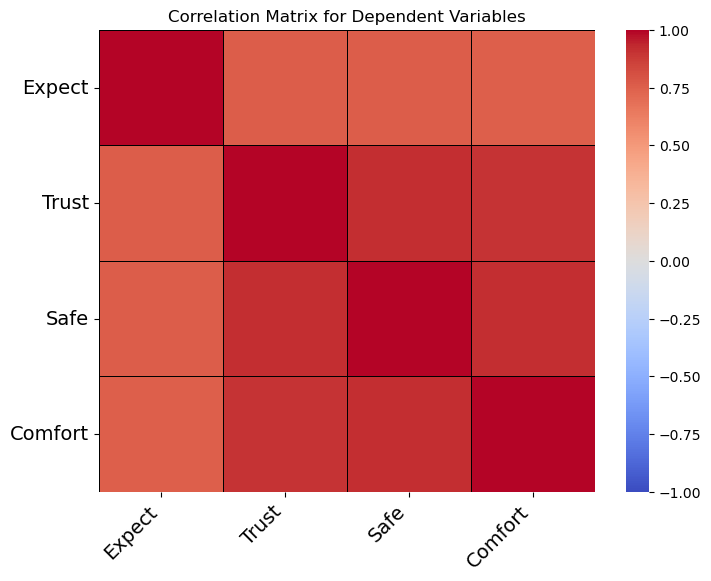

,Expect,Trust,Safe,Comfort
Expect,1.000,0.762,0.763,0.753
Trust,0.762,1.000,0.917,0.900
Safe,0.763,0.917,1.000,0.919
Comfort,0.753,0.900,0.919,1.000


In [185]:
# Select the features to include the correlation matrix
features = ['Expect','Trust', 'Safe', 'Comfort']

# Create the correlation matrix
correlation_matrix = model_data[features].corr()



# Visualize the correlation matrix
plt.figure(figsize = (8, 6))
heatmap = sns.heatmap(correlation_matrix, cmap = 'coolwarm', annot=False, annot_kws = {'size': 20, 'color': 'b'}, fmt = '.2', vmin = -1, vmax = 1, linecolor = 'black', linewidth = '0.5')

# Adjust tick labels sizes
heatmap.tick_params(axis = 'x', labelsize = 14)
heatmap.tick_params(axis = 'y', labelsize = 14)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation = 45, horizontalalignment = 'right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation = 0, horizontalalignment = 'right')
plt.title('Correlation Matrix for Dependent Variables')

# Define the filename with timestamp
filename = 'Correlation Matrix for Dependent Variables'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

correlation_matrix.round(3)

In [ ]:
# Initialize an empty list to store the results
results = []

vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for val in vals:
    features = abs(model_data_with_dummies.corr()['Expect'][abs(model_data_with_dummies.corr()['Expect']) > val].drop('Expect')).index.tolist()

    X = model_data_with_dummies.drop(columns=['Expect'])
    X = X[features]

    y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)

    rmse = round(sqrt(mean_squared_error(y, y_pred)), 2)
    r_squared = round(r2_score(y, y_pred), 2)

    # Append the results as a dictionary
    results.append({
        "Val": val,
        "RMSE": rmse,
        "R_squared": r_squared,
        "Features": features
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Display the DataFrame
results_df

### Identify Multicollinearity among Features

In [ ]:
# Print correlation between each pair of features
# print('Correlation between each pair of features:')
# for i in range(len(model_data_with_dummies.corr().columns)):
#    for j in range(i + 1, len(model_data_with_dummies.corr().columns)):
#        feature1 = model_data_with_dummies.corr().columns[i]
#        feature2 = model_data_with_dummies.corr().columns[j]
#        correlation_value = model_data_with_dummies.corr().iloc[i,j]
#        print(f"{feature1} and {feature2}: {correlation_value:.2f}")

### Building Linear Regression

In [ ]:
# Separate features and target variables
X = model_data_with_dummies.drop(columns=['Trust','Safe','Comfort','Expect'])
y = model_data_with_dummies.Trust

# Normlize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Adding a columns of 1s to X which will act as an intercept term
X_b_scaled = np.c_[np.ones((len(X_scaled),1)),X_scaled]
# print(X_b_scaled.shape, X_scaled.shape, y.shape)

def loss_function(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)

    # Mean Squared Error
    mse = round((1/(2*m))*np.sum(np.square(predictions-y)),2)

    # Mean Absolute Error
    mae = round(np.mean(np.abs(predictions - y)),2)

    # Root Mean Squared Error
    rmse = round(np.sqrt(mse),2)

    # R-Squared
    sse = np.sum((predictions - y)**2)
    sst = np.sum((y - np.mean(y))**2)
    r2 = round(1 -(sse/sst),2)
    
    return mse, mae, rmse, r2

def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    cost_history = np.zeros(epochs)

    # Initialize an empty list to store results
    results = []

    for i in range(epochs):
        predictions = X.dot(theta)
        gradients = X.T.dot((predictions - y))
        theta = theta - (1/m) * learning_rate * gradients
        cost_history[i], _, _, _ = loss_function(X, y, theta)
        
        if i % 50 == 0:
            mse, mae, rmse, r2 = loss_function(X, y, theta)
            results.append({
                'epoch': i + 1,
                'MSE': mse,
                'MAE': mae,
                'RMSE': rmse,
                'R-squared': r2
            })

    # Create a DataFrame from the results
    results_df = pd.DataFrame(results)

    # Print the DataFrame
    print(results_df)

    # Plot the DataFrame and save it as an image
    fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the size as needed
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=results_df.values, colLabels=results_df.columns, cellLoc='center', loc='center')

    # Define the filename with timestamp
    filename = 'Gradient Descent Results.png'
    plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

    return np.round(theta, 2), cost_history

# Initialize
theta = np.random.randn(X_b_scaled.shape[1])

# Set hyperparameters
learning_rate = 0.1
epochs = 1501

# Train the model
theta, cost_history = gradient_descent(X_b_scaled, y, theta, learning_rate, epochs)

def predict(X, theta):
    X_b = np.c_[np.ones((len(X),1)), X]
    return X_b.dot(theta)

# Predictions
predictions = predict(X_scaled, theta)
# print('Predictions:', predictions)

# Print the coefficiants for specific columns
index_user_speed = X.columns.get_loc('User_Relative_Speed') + 1
index_frechet_distance = X.columns.get_loc('Frechet_Distance') + 1
print('Coefficiants for User_Relative_Speed',theta[index_user_speed])
print('Coefficiants for Frechet_Distance',theta[index_frechet_distance])

### Build K-means Clustering

In [215]:
model_data_for_transition_matrix['Differences_in_Trust'] = (model_data_for_transition_matrix['Trust'] - model_data_for_transition_matrix['Trust_before']).abs()

In [216]:
model_data_for_transition_matrix.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Frechet_Distance,Gaze_on_AGV,User_Relative_Speed,User_Trajectory,AGV_Approaching,AGV_User_Combination,AGV_Path_Complexity,Interaction No,Trust_before,Differences_in_Trust
0,1,High,2024-5-3,14,28,53,1,15:2:48,15:3:38,219,...,NaN,0.063,137.683,Diagonal,North,North - Diagonal,Complex,1,4.9,5.1
1,1,High,2024-5-3,14,28,53,2,15:3:47,15:4:29,0,...,NaN,0.038,109.577,Straight,South,South - Straight,Straight,2,10.0,0.0
2,1,High,2024-5-3,14,28,53,3,15:4:37,15:5:34,268,...,NaN,0.069,131.592,Diagonal,South,South - Diagonal,Complex,3,10.0,0.0
3,1,High,2024-5-3,14,28,53,4,15:5:46,15:6:37,779,...,NaN,0.231,95.205,Straight,Northeast,Northeast - Straight,Complex,4,10.0,3.0
4,1,High,2024-5-3,14,28,53,5,15:6:41,15:7:44,868,...,NaN,0.234,185.999,Straight,Northwest,Northwest - Straight,Complex,5,7.0,2.0


In [307]:
# Encode the categorical data
categorical_columns = ['PID', 'DRate','User_Trajectory', 'AGV_Approaching']
encoder = OneHotEncoder(sparse_output = False)
encoded_categories = encoder.fit_transform(model_data_for_transition_matrix[categorical_columns])


# Normlizing the Data
numerical_columns = ['User_Relative_Speed','Differences_in_Trust']
scaler = StandardScaler()
normlized_data = scaler.fit_transform(model_data_for_transition_matrix[numerical_columns])

In [308]:
# Concatenate the encoded and normlized categories
data_for_clustering = np.concatenate([encoded_categories, normlized_data], axis = 1)

# Turn the data into a dataframe
columns = list(encoder.get_feature_names_out(categorical_columns)) + numerical_columns

data_for_clustering = pd.DataFrame(data_for_clustering, columns = columns)

In [316]:
data_for_clustering = data_for_clustering.fillna(0)

In [317]:
data_for_clustering.isna().sum()

PID_1                        0
PID_2                        0
PID_3                        0
PID_4                        0
PID_6                        0
PID_7                        0
PID_8                        0
PID_9                        0
PID_10                       0
PID_11                       0
PID_12                       0
PID_13                       0
PID_14                       0
PID_15                       0
PID_16                       0
PID_17                       0
PID_19                       0
PID_20                       0
PID_21                       0
PID_22                       0
PID_24                       0
PID_26                       0
PID_27                       0
PID_28                       0
PID_29                       0
PID_30                       0
PID_31                       0
PID_32                       0
PID_33                       0
PID_34                       0
PID_35                       0
PID_36                       0
PID_37  

In [318]:
data_for_clustering.columns

Index(['PID_1', 'PID_2', 'PID_3', 'PID_4', 'PID_6', 'PID_7', 'PID_8', 'PID_9',
       'PID_10', 'PID_11', 'PID_12', 'PID_13', 'PID_14', 'PID_15', 'PID_16',
       'PID_17', 'PID_19', 'PID_20', 'PID_21', 'PID_22', 'PID_24', 'PID_26',
       'PID_27', 'PID_28', 'PID_29', 'PID_30', 'PID_31', 'PID_32', 'PID_33',
       'PID_34', 'PID_35', 'PID_36', 'PID_37', 'PID_38', 'PID_39', 'PID_40',
       'PID_41', 'PID_42', 'PID_43', 'PID_44', 'PID_45', 'PID_46',
       'DRate_High', 'DRate_Low', 'User_Trajectory_Diagonal',
       'User_Trajectory_Straight', 'AGV_Approaching_East',
       'AGV_Approaching_North', 'AGV_Approaching_Northeast',
       'AGV_Approaching_Northwest', 'AGV_Approaching_South',
       'AGV_Approaching_Southeast', 'AGV_Approaching_Southwest',
       'AGV_Approaching_West', 'User_Relative_Speed', 'Differences_in_Trust'],
      dtype='object')

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the envir

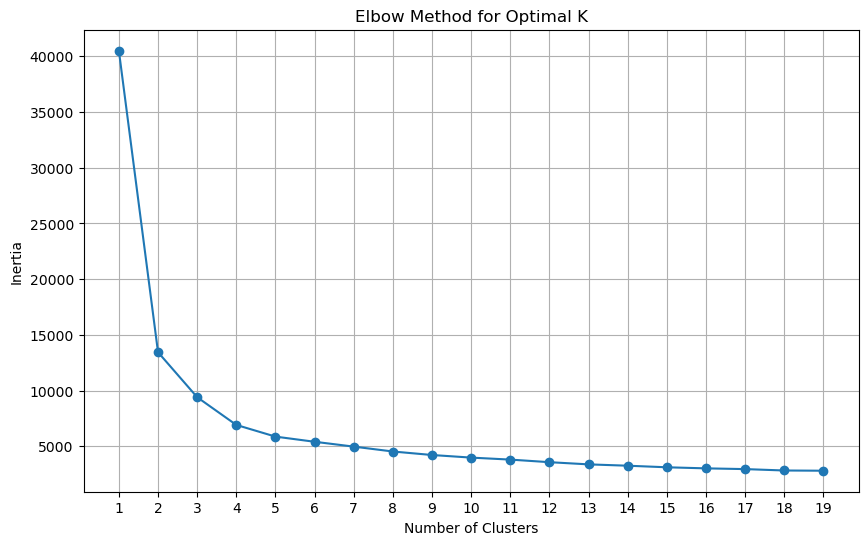

In [328]:
# Identifying the Optimal Number of Clusters
cluster_range = range(1, 20)
inertia = []

for k in cluster_range:
    kmeans = KMeans(n_clusters = k, random_state = 2024)
    kmeans.fit(data_for_clustering)
    inertia.append(kmeans.inertia_)

# Generate the elbow plot
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, 'o-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(cluster_range)
plt.grid(True)

# Define the filename with timestamp
filename = 'Elbow Method for Optimal K'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [329]:
kmeans = KMeans(n_clusters = 5)

kmeans.fit(data_for_clustering)

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


KMeans(n_clusters=5)

In [330]:
data_for_clustering['kmeans_result'] = kmeans.labels_

In [331]:
data_for_clustering.iloc[20:40]

,PID_1,PID_2,PID_3,PID_4,PID_6,PID_7,PID_8,PID_9,PID_10,PID_11,...,AGV_Approaching_North,AGV_Approaching_Northeast,AGV_Approaching_Northwest,AGV_Approaching_South,AGV_Approaching_Southeast,AGV_Approaching_Southwest,AGV_Approaching_West,User_Relative_Speed,Differences_in_Trust,kmeans_result
20,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.377687,-0.604013,1
21,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.460451,-0.604013,0
22,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.376782,0.285263,1
23,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.178889,1.174540,3
24,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.116864,1.174540,3
25,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.828543,1.174540,3
26,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.552200,-0.604013,4
27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.031725,-0.604013,2
28,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.666316,-0.604013,1
29,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.810710,-0.604013,0


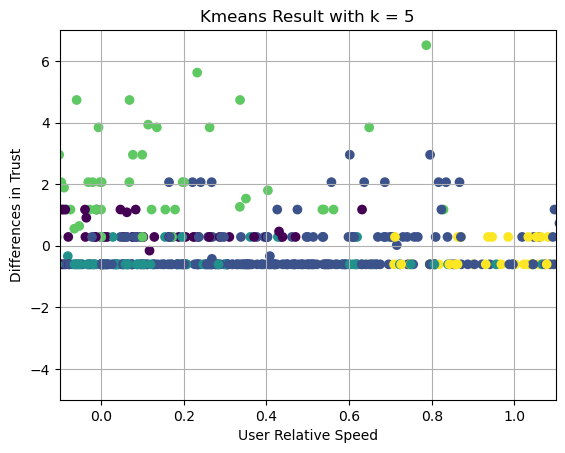

In [332]:
# Plotting the result
plt.scatter(x=data_for_clustering['User_Relative_Speed'],y=data_for_clustering['Differences_in_Trust'] ,c=data_for_clustering['kmeans_result'])
plt.xlim(-0.1,1.1)
plt.ylim(-5,7)
plt.title('Kmeans Result with k = 5')
plt.xlabel('User Relative Speed')
plt.ylabel('Differences in Trust')
plt.grid(True)

# Define the filename with timestamp
filename = 'Kmeans Result with k = 5'
plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### POMDP:

#### **States (S)**: The set of possible underlying states of the system. In a POMDP, these states are not directly observable. State: (Relative distance between AGV and human (Ecludican), AGV speed). We can defenitly look for other things. 

#### **Observations (O)**: The set of possible observations that the agent can make. Observations provide partial information about the true state of the system.

#### **Actions (A)**: Changing the deceleration rate from 0 to 0.7.

#### **Transition Probability (P)**: A Matrix describing the probability of transitioning from one state to another given a particular action. 

#### **Observation Model (O)**: Describes the probability of making a particular observation given the true state of the system.

#### **Reward Function (R)**: The reward function (human trust rating) is given after several steps. Thus, the structure of the reward function can be based on some intermediate rewards which are based on observable proxies of trust (User Relative Speed and Frechet Distance) and a final rewards based on the overall trust.

##### Intermediate Rewards Components: 1. Relative Speed: We can change the current definition to an expected or optimal speed. 2. Frechet Distance: Measuring the similarity between the user's actual path and the expected trajectory.
##### Reward Function: 
##### $r_t = -(w_1 \times speed\_diff + w_2 \times frechet\_dist)$
##### $R_{final} = trust\_rating$
